In [1]:
import h5py
import numpy as np
import glob
from torch.utils.data import Dataset, DataLoader
import torchcvnn.nn as c_nn
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F


### Test loading

In [2]:
path = "/mnt/i/mridata/brain_multicoil_train_batch_0/multicoil_train/file_brain_AXT2_200_2000057.h5"

In [2]:
# activations_to_test = ["modrelu", "zrelu", "cardioid", "c_relu", "c_sigmoid", "c_tanh", "c_elu", "c_gelu"]
activations_to_test = ["modrelu", "zrelu", "cardioid", "c_relu"]
# activations_to_test = ["zrelu", "cardioid", "c_relu"]

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
with h5py.File(path, "r") as f:
    print("Keys:", list(f.keys()))
    kspace = f["kspace"][:]      # raw k-space
    print("kspace shape:", kspace.shape, "dtype:", kspace.dtype)

    if "reconstruction_rss" in f:
        rss = f["reconstruction_rss"][:]
        print("reconstruction_rss shape:", rss.shape, "dtype:", rss.dtype)

    # look at attributes (metadata)
    attrs = dict(f.attrs)
    print("Attributes:", attrs.keys())

NameError: name 'path' is not defined

In [ ]:
s = kspace.shape[0] // 2
k_slice = kspace[s]  # [coils, Ny, Nx]
rss_slice = rss[s]   # [Ny, Nx] (if available)

In [ ]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("k-space (log-magnitude, coil 0)")
plt.imshow(np.log1p(np.abs(k_slice[0])), cmap='gray')
plt.axis('off')

In [ ]:
if rss is not None:
    plt.subplot(1,2,2)
    plt.title("RSS Image")
    plt.imshow(rss_slice, cmap='gray')
    plt.axis('off')
else:
    img = np.fft.ifft2(k_slice, norm='ortho')
    img_rss = np.sqrt(np.sum(np.abs(img)**2, axis=0))
    plt.subplot(1,2,2)
    plt.title("RSS Image (computed)")
    plt.imshow(img_rss, cmap='gray')
    plt.axis('off')

plt.show()

In [ ]:
def simple_mask(Ny, accel=4):
    mask = np.zeros(Ny, dtype=np.float32)
    mask[::accel] = 1.0
    # keep some low-frequency center lines
    center = Ny // 2
    mask[center-4:center+4] = 1.0
    return mask

Ny, Nx = k_slice.shape[1], k_slice.shape[2]
mask = simple_mask(Ny, accel=4)[:, None]   # [Ny,1]
k_und = k_slice * mask                     # [coils,Ny,Nx]


# Full recon in image space
img_full = np.fft.ifft2(k_slice, norm="ortho")        # [coils,Ny,Nx]
img_full_rss = np.sqrt(np.sum(np.abs(img_full)**2, axis=0))  # [Ny,Nx]

# SHIFT for visualization
img_full_rss_disp = np.fft.fftshift(img_full_rss)  


# IFFT in image space
img_und = np.fft.ifft2(k_und, norm="ortho")          # [coils,Ny,Nx]
img_und_rss = np.sqrt(np.sum(np.abs(img_und)**2, axis=0))   # [Ny,Nx]

# fftshift only for display
img_und_rss_disp  = np.fft.fftshift(img_und_rss)
img_full_rss_disp = np.fft.fftshift(img_full_rss)   # from before

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Full RSS (shifted)")
plt.imshow(img_full_rss_disp, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Undersampled k-space (coil 0)")
plt.imshow(np.log1p(np.abs(k_und[0])), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Undersampled RSS Recon (shifted)")
plt.imshow(img_und_rss_disp, cmap="gray")
plt.axis("off")
plt.show()


In [6]:
def rss_combine(img_mc):
    """
    Root-sum-of-squares coil combination.
    img_mc: [num_coils, Ny, Nx], complex
    returns: [Ny, Nx], real
    """
    return torch.sqrt((img_mc.abs() ** 2).sum(dim=0) + 1e-8)

In [5]:
def simple_mask(Ny, accel=4, device="cpu"):
    mask = torch.zeros(Ny, dtype=torch.float32, device=device)
    mask[::accel] = 1.0
    center = Ny // 2
    mask[center-4:center+4] = 1.0
    return mask


### For bulk dataset in the folder

In [7]:
class FastMRIDataset(Dataset):
    def __init__(self, h5_paths, accel=4, max_slices=None):
        self.paths = h5_paths
        self.accel = accel

        self.samples = []  # list of (path, slice_idx)
        for p in self.paths:
            with h5py.File(p, "r") as f:
                num_slices = f["kspace"].shape[0]
            for s in range(num_slices):
                self.samples.append((p, s))
                if max_slices is not None and len(self.samples) >= max_slices:
                    break
            if max_slices is not None and len(self.samples) >= max_slices:
                break

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, s = self.samples[idx]
        with h5py.File(path, "r") as f:
            kspace = f["kspace"][s]           # [num_coils, Ny, Nx], complex64
            kspace = torch.from_numpy(kspace)  # complex64

            Ny, Nx = kspace.shape[-2], kspace.shape[-1]
            mask = simple_mask(Ny, accel=self.accel).to(kspace.device)
            mask = mask[:, None]             # [Ny,1]
            kspace_und = kspace * mask       # [coils,Ny,Nx]

        # IFFT2 coil-wise: k-space -> image domain
        img_full_mc = torch.fft.ifft2(kspace, norm="ortho")      # [coils,Ny,Nx] complex
        img_und_mc  = torch.fft.ifft2(kspace_und, norm="ortho")  # [coils,Ny,Nx] complex

        # Coil-combined complex ground truth and input (simple sum over coils)
        img_full_comb = img_full_mc.sum(dim=0)   # [Ny,Nx] complex
        img_und_comb  = img_und_mc.sum(dim=0)    # [Ny,Nx] complex

        X_complex = img_und_comb.unsqueeze(0)    # [1,H,W] complex
        Y_complex = img_full_comb.unsqueeze(0)   # [1,H,W] complex

        return X_complex, Y_complex


### For single files

In [8]:
class SingleFastMRIDataset(Dataset):
    def __init__(self, path, accel=4, max_slices=None):
        self.path = path
        self.accel = accel

        with h5py.File(self.path, "r") as f:
            num_slices = f["kspace"].shape[0]

        self.slice_indices = list(range(num_slices))
        if max_slices is not None:
            self.slice_indices = self.slice_indices[:max_slices]

    def __len__(self):
        return len(self.slice_indices)

    def __getitem__(self, idx):
        s = self.slice_indices[idx]
        with h5py.File(self.path, "r") as f:
            kspace = f["kspace"][s]          # [num_coils, Ny, Nx] or [Ny,Nx]
            kspace = torch.from_numpy(kspace)  # complex64

        Ny, Nx = kspace.shape[-2], kspace.shape[-1]
        mask = simple_mask(Ny, accel=self.accel).to(kspace.device)
        mask = mask[:, None]                # [Ny,1]
        kspace_und = kspace * mask

        # image domain
        img_full = torch.fft.ifft2(kspace, norm="ortho")      # complex
        img_und  = torch.fft.ifft2(kspace_und, norm="ortho")  # complex

        if img_full.ndim == 3:   # [coils,Ny,Nx]
            # coil-combined complex ground truth (simple sum here)
            img_full_comb = img_full.sum(dim=0)   # [Ny,Nx] complex
            img_und_comb  = img_und.sum(dim=0)    # [Ny,Nx] complex
        else:                    # [Ny,Nx]
            img_full_comb = img_full
            img_und_comb  = img_und

        X_complex = img_und_comb.unsqueeze(0)   # [1,H,W] complex
        Y_complex = img_full_comb.unsqueeze(0)  # [1,H,W] complex

        return X_complex, Y_complex


In [9]:
train_path = "/mnt/i/mridata/brain_multicoil_train_batch_0/multicoil_train/train/"
val_path   = "/mnt/i/mridata/brain_multicoil_val_batch_0/multicoil_val/val/"

train_files = sorted(glob.glob(train_path + "*.h5"))
val_files   = sorted(glob.glob(val_path + "*.h5"))

train_ds = FastMRIDataset(train_files, accel=4, max_slices=2000)
val_ds   = FastMRIDataset(val_files,   accel=4, max_slices=500)


# train_path = "/mnt/i/mridata/brain_multicoil_train_batch_0/multicoil_train/file_brain_AXT2_200_2000057.h5"
# val_path   = "/mnt/i/mridata/brain_multicoil_val_batch_0/multicoil_val/file_brain_AXT2_200_2000022.h5"

# train_ds = SingleFastMRIDataset(train_path, accel=4, max_slices=2000)
# val_ds   = SingleFastMRIDataset(val_path,   accel=4, max_slices=500)

cv_train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=4, pin_memory=True)
cv_val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=4, pin_memory=True)

x0, y0 = next(iter(cv_train_loader))
print("X_complex batch:", x0.shape, x0.dtype)  # [B,1,H,W], complex
print("Y_target batch:", y0.shape, y0.dtype)   # [B,1,H,W], float32


ValueError: num_samples should be a positive integer value, but got num_samples=0

In [10]:
def get_complex_activation(name: str):
    name = name.lower()
    if name == "modrelu":
        return c_nn.modReLU()
    elif name == "zrelu":
        return c_nn.zReLU()
    elif name == "cardioid":
        return c_nn.Cardioid()
    elif name == "c_relu":
        return c_nn.CReLU()
    elif name == "c_sigmoid":
        return c_nn.CSigmoid()
    elif name == "c_tanh":
        return c_nn.CTanh()
    elif name == "c_elu":
        return c_nn.CELU()
    elif name == "c_gelu":
        return c_nn.CGELU()
    else:
        return nn.Identity()

In [11]:
def complex_mse(pred, target):

    diff = pred - target

    return (diff.real**2 + diff.imag**2).mean()



In [12]:
class ComplexMRIUNetSmall(nn.Module):
    def __init__(self, act_name="cardioid"):
        super().__init__()
        act = get_complex_activation(act_name)

        # Encoder blocks - Use PyTorch's nn.Conv2d (supports complex!)
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(16),
            act,
            nn.Conv2d(16, 16, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(16),
            act,
        )
        self.pool1 = c_nn.AvgPool2d(kernel_size=2, stride=2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(32),
            act,
            nn.Conv2d(32, 32, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(32),
            act,
        )
        self.pool2 = c_nn.AvgPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(64),
            act,
            nn.Conv2d(64, 64, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(64),
            act,
        )

        # Decoder blocks
        self.up2 = c_nn.ConvTranspose2d(
            64, 32, kernel_size=3, stride=2, padding=1, output_padding=1
        )
        self.dec2 = nn.Sequential(
            c_nn.BatchNorm2d(32),
            act,
            nn.Conv2d(64, 32, kernel_size=3, padding=1, dtype=torch.complex64),  # 32+32=64
            c_nn.BatchNorm2d(32),
            act,
        )

        self.up1 = c_nn.ConvTranspose2d(
            32, 16, kernel_size=3, stride=2, padding=1, output_padding=1
        )
        self.dec1 = nn.Sequential(
            c_nn.BatchNorm2d(16),
            act,
            nn.Conv2d(32, 16, kernel_size=3, padding=1, dtype=torch.complex64),  # 16+16=32
            c_nn.BatchNorm2d(16),
            act,
        )

        # Final conv to 1 channel
        self.out_conv = nn.Conv2d(16, 1, kernel_size=3, padding=1, dtype=torch.complex64)

        # Initialize weights
        self._init_complex_weights()

    def _init_complex_weights(self):
        """
        Initialize complex-valued weights using Kaiming/He initialization.
        For complex weights, we initialize real and imaginary parts independently
        with variance/2 for each part to maintain the overall variance.
        """
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                # if m.weight.is_complex():
                #     # Get weight as view_as_real: [..., 2] where last dim is [real, imag]
                #     weight_real_view = torch.view_as_real(m.weight.data)

                #     # Calculate fan_in for Kaiming initialization
                #     fan_in = m.weight.size(1) * m.kernel_size[0] * m.kernel_size[1]

                #     # Kaiming uniform bound with variance split between real and imag
                #     # For complex: variance should be split, so each part gets sqrt(1/fan_in)
                #     bound = (1.0 / fan_in) ** 0.5

                #     # Initialize real and imaginary parts independently
                #     nn.init.uniform_(weight_real_view[..., 0], -bound, bound)  # real part
                #     nn.init.uniform_(weight_real_view[..., 1], -bound, bound)  # imaginary part

                #     # Update the actual complex weight
                #     m.weight.data = torch.view_as_complex(weight_real_view.contiguous())

                # # Initialize bias if present
                # if m.bias is not None and m.bias.is_complex():
                #     bias_real_view = torch.view_as_real(m.bias.data)
                #     bound = (1.0 / fan_in) ** 0.5
                #     nn.init.uniform_(bias_real_view[..., 0], -bound, bound)
                #     nn.init.uniform_(bias_real_view[..., 1], -bound, bound)
                #     m.bias.data = torch.view_as_complex(bias_real_view.contiguous())

                #----- TORCHCVNN KAIMING INITIALIZATION -----
                # if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, c_nn.ConvTranspose2d)):
                #     if hasattr(m, 'weight') and m.weight is not None:
                #         c_nn.init.complex_kaiming_uniform_(m.weight, mode="fan_in")
                #     if hasattr(m, 'bias') and m.bias is not None and m.bias.is_complex():
                #         nn.init.uniform_(m.bias.real, -0.01, 0.01)
                #         nn.init.uniform_(m.bias.imag, -0.01, 0.01)


                #----- TORCHCVNN XAVIER INITIALIZATION -----
                if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, c_nn.ConvTranspose2d)):
                    if hasattr(m, 'weight') and m.weight is not None:
                        c_nn.init.complex_xavier_uniform_(m.weight)
                    if hasattr(m, 'bias') and m.bias is not None and m.bias.is_complex():
                        nn.init.uniform_(m.bias.real, -0.01, 0.01)
                        nn.init.uniform_(m.bias.imag, -0.01, 0.01)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        # Bottleneck
        b = self.bottleneck(p2)

        # Decoder
        u2 = self.up2(b)
        u2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(u2)

        u1 = self.up1(d2)
        u1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(u1)

        out = self.out_conv(d1)
        return out

In [13]:
def clip_and_norm_log_mag(mag, clip_percent=99.9):
    # log10 magnitude
    logmag = np.log10(mag + 1e-12)
    # clip high end to a percentile to avoid one super-bright DC dominating
    hi = np.percentile(logmag, clip_percent)
    lo = np.percentile(logmag, 1.0)
    logmag = np.clip(logmag, lo, hi)
    vmin, vmax = logmag.min(), logmag.max()
    if vmax > vmin:
        return (logmag - vmin) / (vmax - vmin)
    else:
        return np.zeros_like(logmag)


In [14]:
def visualize_reconstruction_scaled(model, val_loader, num_samples=3, tag="modrelu"):
    model.eval()
    with torch.no_grad():
        x, y = next(iter(val_loader))
        x = x.to(device)        # [B,1,H,W] complex
        y = y.to(device)        # [B,1,H,W] complex

        y_hat = model(x)        # [B,1,H,W] complex

        # Magnitudes for scaling + display
        y_mag     = y.abs()
        y_hat_mag = y_hat.abs()

        tgt_mean  = y_mag.mean().item()
        pred_mean = y_hat_mag.mean().item()
        eps = 1e-8
        scale = pred_mean / (tgt_mean + eps)
        print(f"Scaling target magnitude by factor ≈ {scale:.3e}")

        y_mag_scaled = y_mag * scale  # [B,1,H,W] real

        x_cpu     = x.cpu()
        y_mag_cpu = y_mag_scaled.cpu()
        y_hat_cpu = y_hat_mag.cpu()

        def norm_img(img):
            vmin, vmax = img.min(), img.max()
            if vmax > vmin:
                return (img - vmin) / (vmax - vmin)
            else:
                return np.zeros_like(img)

        # ----- Image-space visualization -----
        fig_img, axes_img = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
        if num_samples == 1:
            axes_img = axes_img.reshape(1, -1)

        for i in range(num_samples):
            in_mag   = np.fft.fftshift(x_cpu[i,0].abs().numpy())
            tgt_mag  = np.fft.fftshift(y_mag_cpu[i,0].numpy())
            pred_mag = np.fft.fftshift(y_hat_cpu[i,0].numpy())

            print(f"[Image] Sample {i}: in[{in_mag.min():.3e},{in_mag.max():.3e}] "
                  f"tgt_scaled[{tgt_mag.min():.3e},{tgt_mag.max():.3e}] "
                  f"pred[{pred_mag.min():.3e},{pred_mag.max():.3e}]")

            in_disp   = norm_img(np.log1p(in_mag))
            tgt_disp  = norm_img(np.log1p(tgt_mag))
            pred_disp = norm_img(np.log1p(pred_mag))

            axes_img[i,0].imshow(in_disp,  cmap="gray")
            axes_img[i,0].set_title("Input (img, fftshift, log)")
            axes_img[i,0].axis("off")

            axes_img[i,1].imshow(tgt_disp, cmap="gray")
            axes_img[i,1].set_title("Target×scale (img, fftshift, log)")
            axes_img[i,1].axis("off")

            axes_img[i,2].imshow(pred_disp, cmap="gray")
            axes_img[i,2].set_title("Prediction (img, fftshift, log)")
            axes_img[i,2].axis("off")
            

        print("orig target mag mean/std:", y_mag.mean().item(), y_mag.std().item())
        print("pred mag mean/std:", y_hat_mag.mean().item(), y_hat_mag.std().item())

        fig_img.suptitle(f"Reconstruction – {tag} (Image space)")
        fig_img.tight_layout()
        plt.show()

        # ----- Fourier-space visualization -----
        fig_k, axes_k = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
        if num_samples == 1:
            axes_k = axes_k.reshape(1, -1)

        for i in range(num_samples):
            # Compute FFT of image-domain complex data
            xin  = x_cpu[i,0].numpy()
            ytgt = y[i,0].cpu().numpy()        # original complex target (unscaled)
            yph  = y_hat[i,0].cpu().numpy()

            k_in   = np.fft.fft2(xin, norm="ortho")
            k_tgt  = np.fft.fft2(ytgt, norm="ortho")
            k_pred = np.fft.fft2(yph, norm="ortho")

            k_in_mag   = np.abs(k_in)
            k_tgt_mag  = np.abs(k_tgt)
            k_pred_mag = np.abs(k_pred)

            print(f"[K-space] Sample {i}: in[{k_in_mag.min():.3e},{k_in_mag.max():.3e}] "
                  f"tgt[{k_tgt_mag.min():.3e},{k_tgt_mag.max():.3e}] "
                  f"pred[{k_pred_mag.min():.3e},{k_pred_mag.max():.3e}]")

            kin_disp   = clip_and_norm_log_mag(k_in_mag)
            ktgt_disp  = clip_and_norm_log_mag(k_tgt_mag)
            kpred_disp = clip_and_norm_log_mag(k_pred_mag)
            
            axes_k[i,0].imshow(kin_disp,   cmap="gray")
            axes_k[i,0].set_title("Input (k-space, log)")
            axes_k[i,0].axis("off")

            axes_k[i,1].imshow(ktgt_disp,  cmap="gray")
            axes_k[i,1].set_title("Target (k-space, log)")
            axes_k[i,1].axis("off")

            axes_k[i,2].imshow(kpred_disp, cmap="gray")
            axes_k[i,2].set_title("Prediction (k-space, log)")
            axes_k[i,2].axis("off")

        fig_k.suptitle(f"Reconstruction – {tag} (K-space)")
        fig_k.tight_layout()
        plt.show()


In [17]:
def calculate_psnr(pred, target, max_val=1.0):
    """Simple PSNR calculation"""
    mse = np.mean((pred - target) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(max_val / np.sqrt(mse))

In [18]:
def train_one_epoch(model, loader, optimizer, epoch, tag="cardioid", log_grad_norm=False):
    model.train()
    total_loss, total = 0.0, 0
    grad_norms = []  # per-batch grad norm if logging

    for x, y in tqdm(loader, desc=f"[{tag}] Train {epoch}", leave=False):
        x = x.to(device)   # complex
        y = y.to(device)   # real

        optimizer.zero_grad()
        y_hat = model(x)   # complex
        loss = complex_mse(y_hat, y)
        loss.backward()

        if log_grad_norm:
            with torch.no_grad():
                # global L2 gradient norm
                sq_sum = 0.0
                for p in model.parameters():
                    if p.grad is not None:
                        sq_sum += p.grad.pow(2).sum().item()
                grad_norm = (sq_sum ** 0.5)
                grad_norms.append(grad_norm)

        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    avg_loss = total_loss / total
    print(f"[{tag}] Epoch {epoch} | loss={avg_loss:.6f}")

    return avg_loss, grad_norms  # avg_loss per epoch, and list of batch norms


In [19]:
def evaluate(model, loader, tag="cardioid"):
    model.eval()
    total_loss, total = 0.0, 0
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"[{tag}] Eval", leave=False):
            x = x.to(device)
            y = y.to(device)
            y_hat = model(x)
            loss = complex_mse(y_hat, y)
            total_loss += loss.item() * x.size(0)
            total += x.size(0)
    avg_loss = total_loss / total
    print(f"[{tag}] Val | loss={avg_loss:.6f}")
    return avg_loss

### LR Sweeping

In [ ]:
def lr_sweep_for_activation(act_name, lrs, num_epochs=10):
    results = {}

    for lr in lrs:
        print(f"\n=== {act_name} | lr={lr} ===")
        model = ComplexMRIUNetSmall(act_name=act_name).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        train_losses = []
        val_losses = []
        grad_norms_epoch = []

        for epoch in range(1, num_epochs + 1):
            train_loss, grad_norms_batch = train_one_epoch(
                model, cv_train_loader, optimizer, epoch,
                tag=f"{act_name}_lr{lr}", log_grad_norm=True
            )
            val_loss = evaluate(model, cv_val_loader, tag=f"{act_name}_lr{lr}")

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            if len(grad_norms_batch) > 0:
                grad_norms_epoch.append(sum(grad_norms_batch) / len(grad_norms_batch))
            else:
                grad_norms_epoch.append(0.0)

        results[lr] = {
            "train_loss": train_losses,
            "val_loss":   val_losses,
            "grad_norm":  grad_norms_epoch,
        }

    return results


In [ ]:
# lrs = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
lrs = [1e-2, 1e-3, 1e-4, 1e-5]
num_epochs = 60

all_results = {}  # all_results[act_name][lr] = dict with curves

for act_name in activations_to_test:
    print(f"\n##### Sweeping LRs for activation: {act_name} #####")
    all_results[act_name] = lr_sweep_for_activation(act_name, lrs, num_epochs=num_epochs)



In [29]:
# Save
# torch.save(all_results, "cvnn_lr_sweep_results_complex.pt")

# Reload
all_results = torch.load("cvnn_lr_sweep_results_complex.pt")


In [ ]:
import csv

def export_results_to_csv(all_results, path="cvnn_lr_sweep_results_complex.csv"):
    """
    all_results[act_name][lr] = {
        'train_loss': [epoch losses],
        'val_loss':   [epoch losses],
        'grad_norm':  [epoch values],
    }
    """
    with open(path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["activation", "lr", "epoch", "train_loss", "val_loss", "grad_norm"])

        for act_name, lr_dict in all_results.items():
            for lr, metrics in lr_dict.items():
                train_loss = metrics["train_loss"]
                val_loss   = metrics["val_loss"]
                grad_norm  = metrics["grad_norm"]
                n_epochs = len(train_loss)
                for epoch in range(n_epochs):
                    writer.writerow([
                        act_name,
                        lr,
                        epoch + 1,
                        train_loss[epoch],
                        val_loss[epoch],
                        grad_norm[epoch],
                    ])

# Call after sweeps:
export_results_to_csv(all_results, "cvnn_lr_sweep_results.csv")


In [27]:
def plot_train_loss_for_activation(all_results, act_name):
    plt.figure(figsize=(8,5))
    for lr, metrics in all_results[act_name].items():
        plt.plot(metrics["train_loss"], label=f"lr={lr}")
    plt.xlabel("Epoch")
    plt.ylabel("Train loss")
    plt.title(f"Train loss vs epoch – {act_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_val_loss_for_activation(all_results, act_name):
    plt.figure(figsize=(8,5))
    for lr, metrics in all_results[act_name].items():
        plt.plot(metrics["val_loss"], label=f"lr={lr}")
    plt.xlabel("Epoch")
    plt.ylabel("Val loss")
    plt.title(f"Val loss vs epoch – {act_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_grad_norm_for_activation(all_results, act_name):
    plt.figure(figsize=(8,5))
    for lr, metrics in all_results[act_name].items():
        plt.plot(metrics["grad_norm"], label=f"lr={lr}")
    plt.xlabel("Epoch")
    plt.ylabel("Avg grad L2 norm per epoch")
    plt.title(f"Grad norm vs epoch – {act_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [110]:
for act_name in activations_to_test:
    plot_train_loss_for_activation(all_results, act_name)
    plot_val_loss_for_activation(all_results, act_name)
    plot_grad_norm_for_activation(all_results, act_name)


KeyError: 'modrelu'

<Figure size 800x500 with 0 Axes>

In [23]:
def plot_train_loss_for_lr(all_results, lr):
    plt.figure(figsize=(8,5))
    for act_name, lr_dict in all_results.items():
        if lr in lr_dict:
            plt.plot(lr_dict[lr]["train_loss"], label=act_name)
    plt.xlabel("Epoch")
    plt.ylabel("Train loss")
    plt.title(f"Train loss vs epoch – lr={lr}")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_val_loss_for_lr(all_results, lr):
    plt.figure(figsize=(8,5))
    for act_name, lr_dict in all_results.items():
        if lr in lr_dict:
            plt.plot(lr_dict[lr]["val_loss"], label=act_name)
    plt.xlabel("Epoch")
    plt.ylabel("Val loss")
    plt.title(f"Val loss vs epoch – lr={lr}")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_grad_norm_for_lr(all_results, lr):
    plt.figure(figsize=(8,5))
    for act_name, lr_dict in all_results.items():
        if lr in lr_dict:
            plt.plot(lr_dict[lr]["grad_norm"], label=act_name)
    plt.xlabel("Epoch")
    plt.ylabel("Avg grad L2 norm per epoch")
    plt.title(f"Grad norm vs epoch – lr={lr}")
    plt.legend()
    plt.grid(True)
    plt.show()

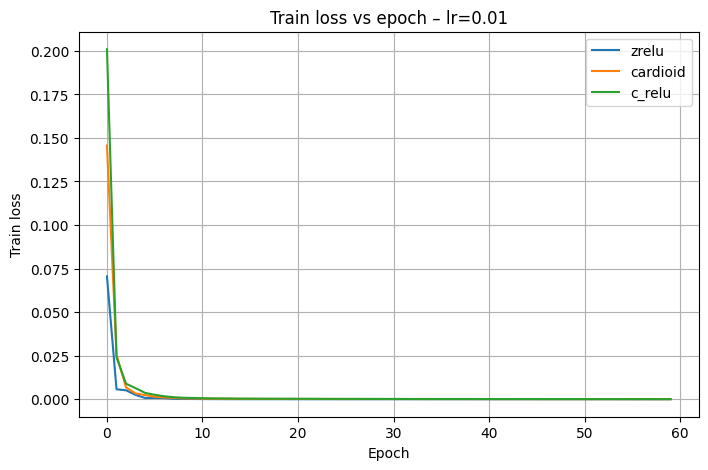

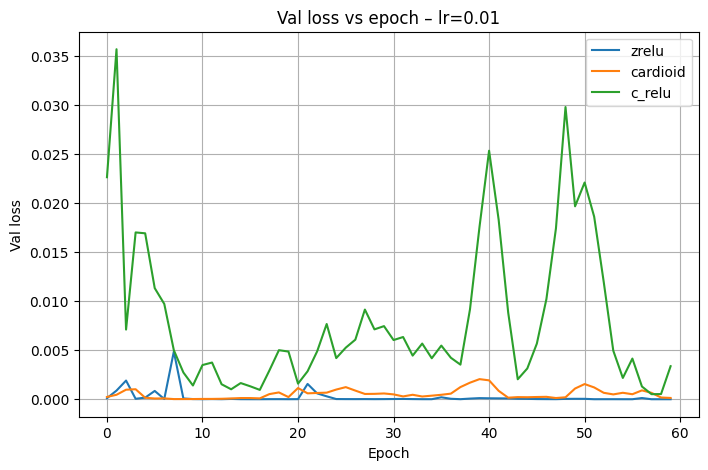

/home/shane/miniconda3/envs/cvnn/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/shane/miniconda3/envs/cvnn/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


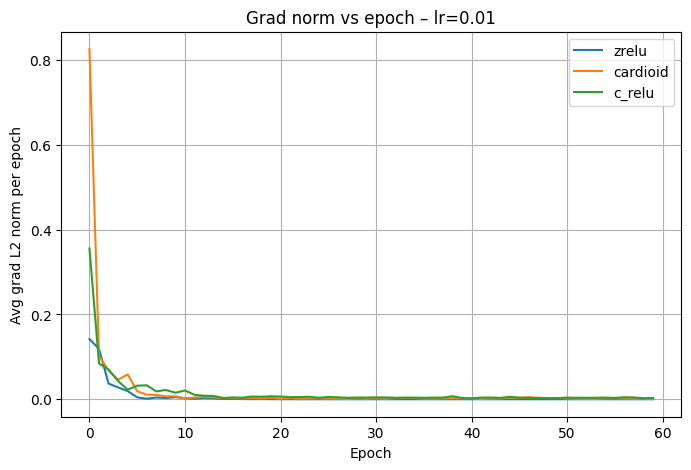

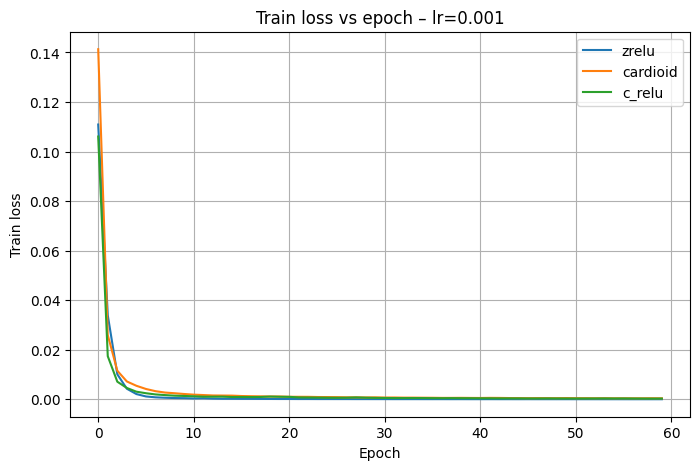

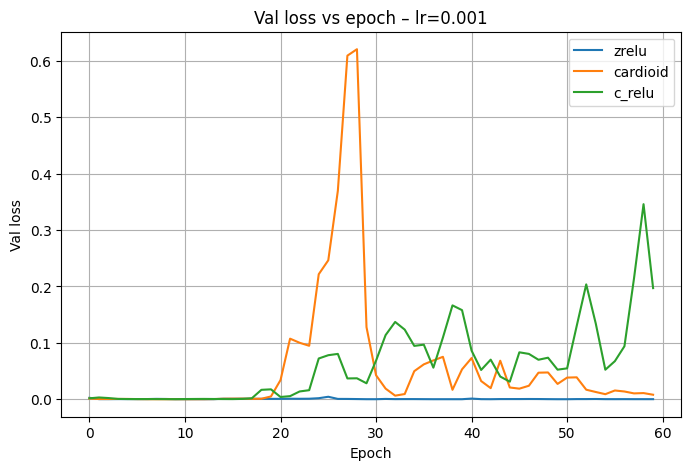

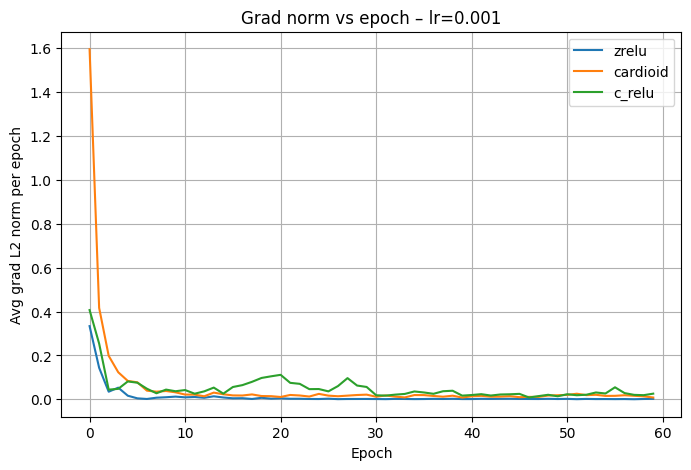

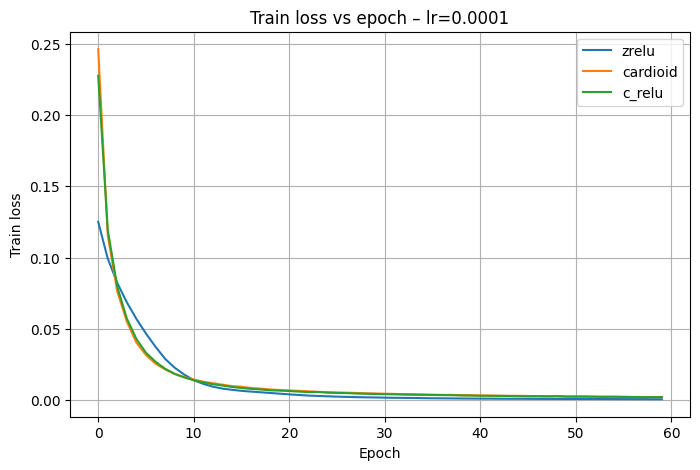

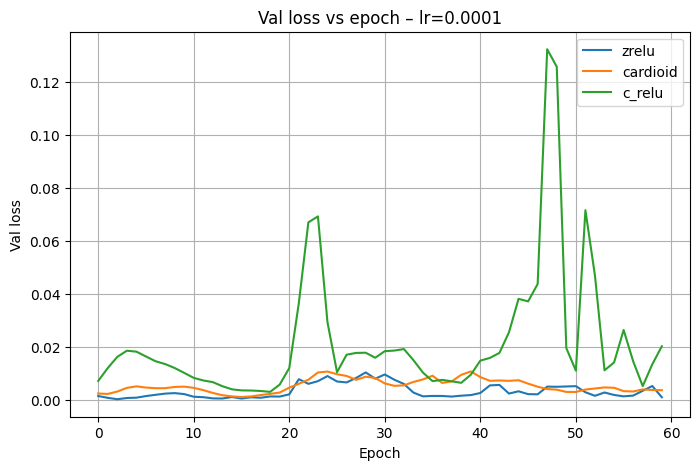

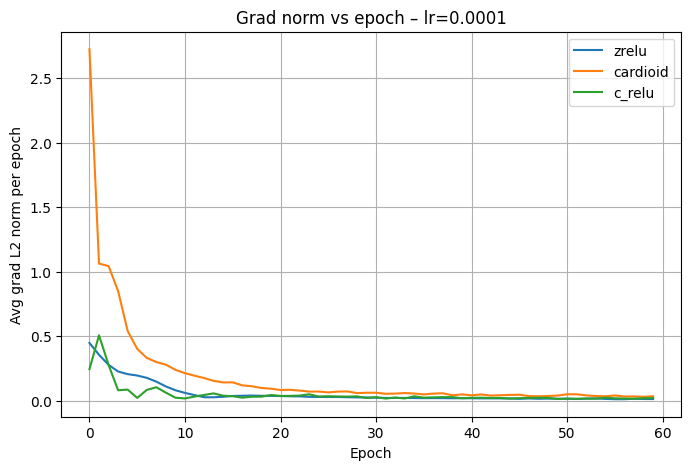

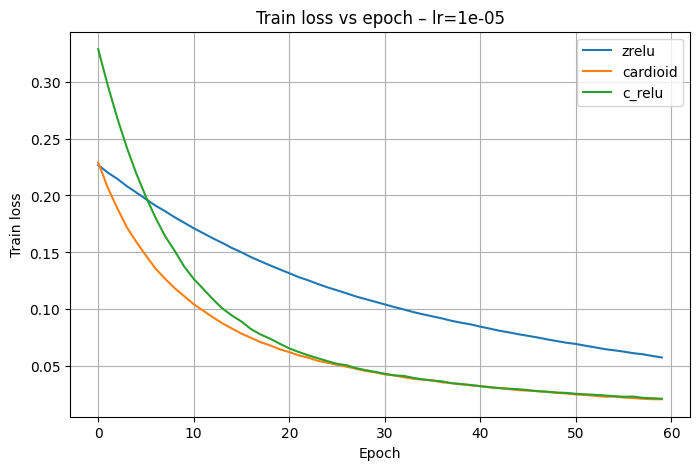

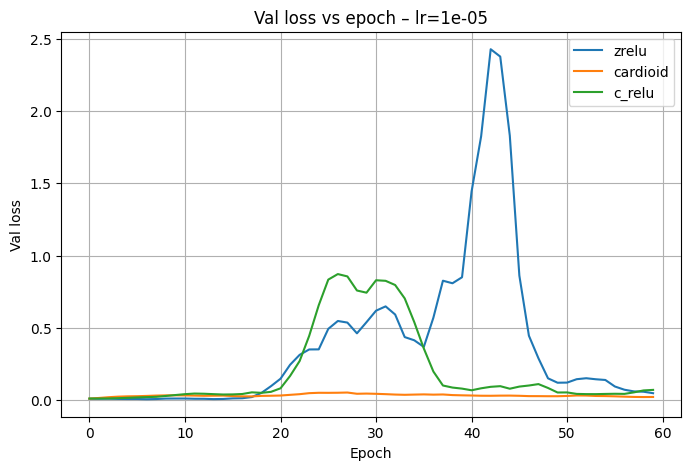

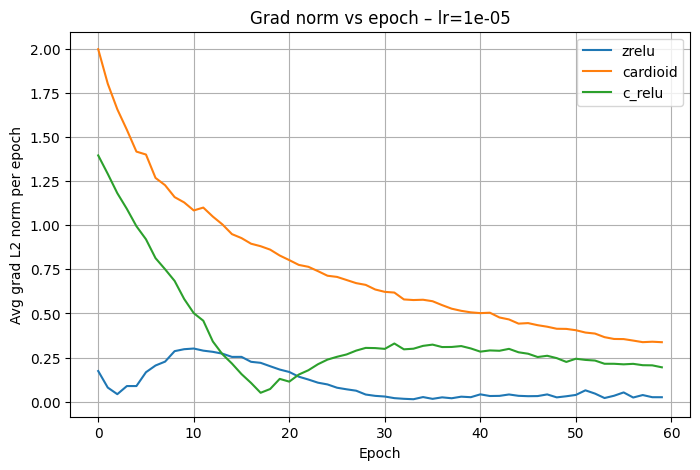

In [24]:
for lr in [1e-2, 1e-3, 1e-4, 1e-5]:
    plot_train_loss_for_lr(all_results, lr=lr)
    plot_val_loss_for_lr(all_results, lr=lr)
    plot_grad_norm_for_lr(all_results, lr=lr)


## This is for single LR running

In [ ]:


step_size = 1e-3

for act_name in activations_to_test:
    print(f"\n=== Testing activation: {act_name} ===")
    model = ComplexMRIUNetSmall(act_name=act_name).to(device)
    optimizer = optim.Adam(model.parameters(), lr=step_size)

    for epoch in range(1, 5):
        train_one_epoch(model, cv_train_loader, optimizer, epoch, act_name)
        evaluate(model, cv_val_loader, act_name)

    visualize_reconstruction_scaled(model, cv_val_loader, num_samples=3, tag=f"{act_name}_epoch{epoch+1}")
    


In [49]:
step_size = 1e-3
act_name = "c_relu"

model = ComplexMRIUNetSmall(act_name=act_name).to(device)
optimizer = optim.Adam(model.parameters(), lr=step_size)

for epoch in range(1, 5):
    train_one_epoch(model, cv_train_loader, optimizer, epoch, act_name)
    evaluate(model, cv_val_loader, act_name)


[c_relu] Epoch 1 | loss=0.368832


[c_relu] Val | loss=0.007933


[c_relu] Epoch 2 | loss=0.030247


[c_relu] Val | loss=0.006384


[c_relu] Epoch 3 | loss=0.018636


[c_relu] Val | loss=0.658456


[c_relu] Epoch 4 | loss=0.013073


[c_relu] Val | loss=4.602694


Scaling target magnitude by factor ≈ 5.972e+04
[Image] Sample 0: in[4.469e-08,2.943e-04] tgt_scaled[2.419e-03,3.783e+01] pred[2.165e-02,4.153e+00]
orig target mag mean/std: 3.464300971245393e-05 5.1075989176752046e-05
pred mag mean/std: 2.0694234371185303 0.5342674255371094


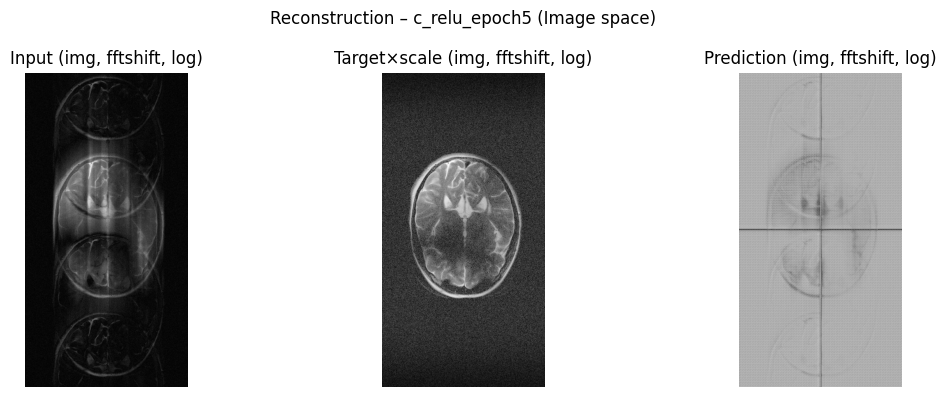

[K-space] Sample 0: in[0.000e+00,8.156e-03] tgt[1.257e-08,8.156e-03] pred[3.850e-05,1.005e+03]


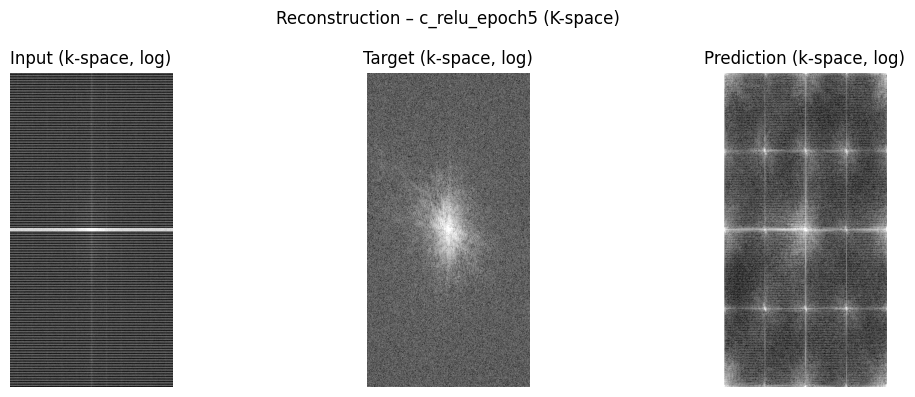

In [50]:
visualize_reconstruction_scaled(model, cv_val_loader, num_samples=1, tag=f"{act_name}_epoch{epoch+1}")

# REAL NETWORK

In [20]:
class SingleFastMRIDatasetReal(Dataset):
    def __init__(self, path, accel=4, max_slices=None):
        self.inner = SingleFastMRIDataset(path, accel=accel, max_slices=max_slices)

    def __len__(self):
        return len(self.inner)

    def __getitem__(self, idx):
        X_complex, Y_complex = self.inner[idx]    # both [1,H,W] complex

        # Input: 2‑channel real [2,H,W]
        Xr = torch.view_as_real(X_complex)        # [1,H,W,2]
        Xr = Xr.squeeze(0).permute(2, 0, 1)       # [2,H,W]

        # Target: 2‑channel real [2,H,W]
        Yr = torch.view_as_real(Y_complex)        # [1,H,W,2]
        Yr = Yr.squeeze(0).permute(2, 0, 1)       # [2,H,W]

        return Xr.float(), Yr.float()


In [21]:
train_ds_real = SingleFastMRIDatasetReal(train_path, accel=4, max_slices=2000)
val_ds_real   = SingleFastMRIDatasetReal(val_path,   accel=4, max_slices=500)

rv_train_loader = DataLoader(train_ds_real, batch_size=4, shuffle=True,
                             num_workers=4, pin_memory=True)
rv_val_loader   = DataLoader(val_ds_real,   batch_size=4, shuffle=False,
                             num_workers=4, pin_memory=True)


In [18]:
class RealMRIUNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        act = nn.ReLU(inplace=True)

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            act,
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            act,
        )
        self.pool1 = nn.AvgPool2d(2, 2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            act,
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            act,
        )
        self.pool2 = nn.AvgPool2d(2, 2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            act,
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            act,
        )

        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec2 = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            act,
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            act,
        )

        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec1 = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            act,
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            act,
        )

        self.out_conv = nn.Conv2d(16, 2, kernel_size=3, padding=1)  # 2 channels: Re, Im

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        u2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(u2)

        u1 = self.up1(d2)
        u1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(u1)

        out = self.out_conv(d1)   # [B,2,H,W]
        return out


In [23]:
def visualize_reconstruction_scaled_real(model, val_loader, num_samples=3, tag="RealUNet"):
    model.eval()
    with torch.no_grad():
        x, y = next(iter(val_loader))
        x = x.to(device)      # [B,2,H,W] float  (Re, Im)
        y = y.to(device)      # [B,2,H,W] float  (Re, Im)

        y_hat = model(x)      # [B,2,H,W] float

        x_cpu     = x.cpu()
        y_cpu     = y.cpu()
        y_hat_cpu = y_hat.cpu()

        def norm_img(img):
            vmin, vmax = img.min(), img.max()
            if vmax > vmin:
                return (img - vmin) / (vmax - vmin)
            else:
                return np.zeros_like(img)

        fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
        if num_samples == 1:
            axes = axes.reshape(1, -1)

        for i in range(num_samples):
            # Reconstruct complex images from 2 channels
            x_complex     = x_cpu[i,0].numpy() + 1j * x_cpu[i,1].numpy()
            y_complex     = y_cpu[i,0].numpy() + 1j * y_cpu[i,1].numpy()
            y_hat_complex = y_hat_cpu[i,0].numpy() + 1j * y_hat_cpu[i,1].numpy()

            in_mag   = np.fft.fftshift(np.abs(x_complex))
            tgt_mag  = np.fft.fftshift(np.abs(y_complex))
            pred_mag = np.fft.fftshift(np.abs(y_hat_complex))

            print(f"Sample {i}: in[{in_mag.min():.3e},{in_mag.max():.3e}] "
                  f"tgt[{tgt_mag.min():.3e},{tgt_mag.max():.3e}] "
                  f"pred[{pred_mag.min():.3e},{pred_mag.max():.3e}]")

            # Optional: boost target magnitude for visualization only
            tgt_boost = tgt_mag * 1e3  # adjust factor if needed

            in_disp   = norm_img(np.log1p(in_mag))
            tgt_disp  = norm_img(np.log1p(tgt_boost))
            pred_disp = norm_img(np.log1p(pred_mag))

            axes[i,0].imshow(in_disp,   cmap="gray")
            axes[i,0].set_title("Input (fftshift, log)")
            axes[i,0].axis("off")

            axes[i,1].imshow(tgt_disp,  cmap="gray")
            axes[i,1].set_title("Target (scaled, fftshift, log)")
            axes[i,1].axis("off")

            axes[i,2].imshow(pred_disp, cmap="gray")
            axes[i,2].set_title("Prediction (fftshift, log)")
            axes[i,2].axis("off")

        # Stats on complex magnitudes
        y_mag     = torch.sqrt(y[:,0]**2 + y[:,1]**2)
        y_hat_mag = torch.sqrt(y_hat[:,0]**2 + y_hat[:,1]**2)
        print("orig target mag mean/std:", y_mag.mean().item(), y_mag.std().item())
        print("pred mag mean/std:", y_hat_mag.mean().item(), y_hat_mag.std().item())

        plt.suptitle(f"Reconstruction – {tag}")
        plt.tight_layout()
        plt.show()


In [24]:
def real_complex_mse(pred, target):

    diff = pred - target
    return (diff ** 2).mean()


In [25]:
def train_one_epoch_real(model, loader, optimizer, epoch, tag="Real", log_grad_norm=False):
    model.train()
    total_loss, total = 0.0, 0
    grad_norms = []

    for x, y in tqdm(loader, desc=f"[{tag}] Train {epoch}", leave=False):
        x = x.to(device)   # [B,2,H,W] float
        y = y.to(device)   # [B,1,H,W] float

        optimizer.zero_grad()
        y_hat = model(x)   # [B,1,H,W] float
        loss = real_complex_mse(y_hat, y)
        loss.backward()

        if log_grad_norm:
            with torch.no_grad():
                sq_sum = 0.0
                for p in model.parameters():
                    if p.grad is not None:
                        sq_sum += p.grad.pow(2).sum().item()
                grad_norms.append(sq_sum ** 0.5)

        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    avg_loss = total_loss / total
    print(f"[{tag}] Epoch {epoch} | loss={avg_loss:.6f}")

    return avg_loss, grad_norms



def evaluate_real(model, loader, tag="Real"):
    model.eval()
    total_loss, total = 0.0, 0
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"[{tag}] Eval", leave=False):
            x = x.to(device)
            y = y.to(device)
            y_hat = model(x)
            loss = real_complex_mse(y_hat, y)
            total_loss += loss.item() * x.size(0)
            total += x.size(0)
    avg_loss = total_loss / total
    print(f"[{tag}] Val | loss={avg_loss:.6f}")
    return avg_loss


In [87]:
real_model = RealMRIUNetSmall().to(device)
optimizer_real = optim.Adam(real_model.parameters(), lr=1e-3)

for epoch in range(0, 15):
    train_one_epoch_real(real_model, rv_train_loader, optimizer_real, epoch, tag="RealUNet")
    evaluate_real(real_model, rv_val_loader, tag="RealUNet")


[RealUNet] Epoch 0 | loss=0.083296


[RealUNet] Val | loss=0.001160


[RealUNet] Epoch 1 | loss=0.012149


[RealUNet] Val | loss=0.001880


[RealUNet] Epoch 2 | loss=0.005844


...

[RealUNet] Val | loss=0.000038


[RealUNet] Epoch 13 | loss=0.000633


[RealUNet] Val | loss=0.000047


[RealUNet] Epoch 14 | loss=0.000573


[RealUNet] Val | loss=0.000103


Sample 0: in[4.469e-08,2.943e-04] tgt[4.051e-08,6.335e-04] pred[9.995e-04,1.089e-01]
orig target mag mean/std: 3.464300971245393e-05 5.1075989176752046e-05
pred mag mean/std: 0.01290994230657816 0.006329694297164679


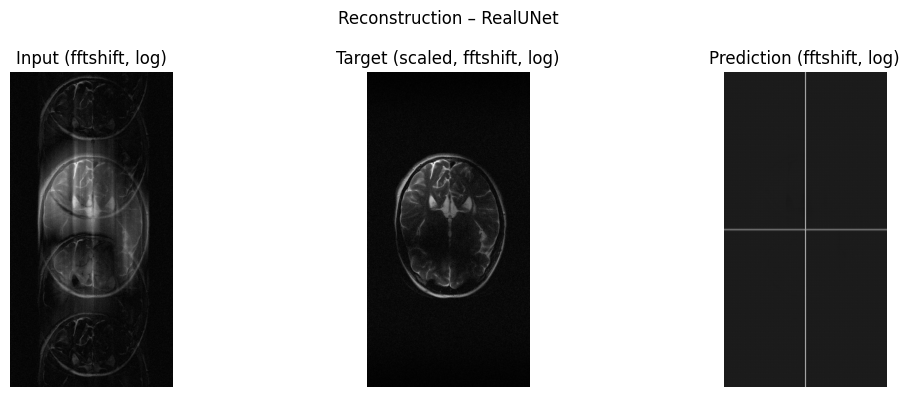

In [88]:
visualize_reconstruction_scaled_real(real_model, rv_val_loader, num_samples=1, tag="RealUNet")

In [ ]:
def run_real_unet_experiment(num_epochs=60, lr=1e-3, tag="RealUNet"):
    model = RealMRIUNetSmall().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    grad_norms_epoch = []

    for epoch in range(1, num_epochs + 1):
        train_loss, grad_norms_batch = train_one_epoch_real(
            model, rv_train_loader, optimizer, epoch, tag=tag, log_grad_norm=True
        )
        val_loss = evaluate_real(model, rv_val_loader, tag=tag)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        if grad_norms_batch:
            grad_norms_epoch.append(sum(grad_norms_batch) / len(grad_norms_batch))
        else:
            grad_norms_epoch.append(0.0)

    results = {
        "model": model,
        "train_loss": train_losses,
        "val_loss": val_losses,
        "grad_norm": grad_norms_epoch,
    }
    return results

In [ ]:
real_results = {}

for lr in [1e-2, 1e-3, 1e-4, 1e-5]:
    real_results[lr] = run_real_unet_experiment(num_epochs=60, lr=lr, tag="RealUNet")


In [19]:
# torch.save(real_results, f"real_unet_results_complex.pt")

real_results = torch.load("real_unet_results_complex.pt", weights_only=False)

In [78]:

def plot_real_train_loss(real_results, title="RealUNet – train loss vs epoch"):
    plt.figure(figsize=(8,5))
    for lr, metrics in real_results.items():
        plt.plot(metrics["train_loss"], label=f"lr={lr}")
    plt.xlabel("Epoch")
    plt.ylabel("Train loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_real_val_loss(real_results, title="RealUNet – val loss vs epoch"):
    plt.figure(figsize=(8,5))
    for lr, metrics in real_results.items():
        plt.plot(metrics["val_loss"], label=f"lr={lr}")
    plt.xlabel("Epoch")
    plt.ylabel("Val loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_real_grad_norm(real_results, title="RealUNet – grad norm vs epoch"):
    plt.figure(figsize=(8,5))
    for lr, metrics in real_results.items():
        plt.plot(metrics["grad_norm"], label=f"lr={lr}")
    plt.xlabel("Epoch")
    plt.ylabel("Avg grad L2 norm per epoch")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


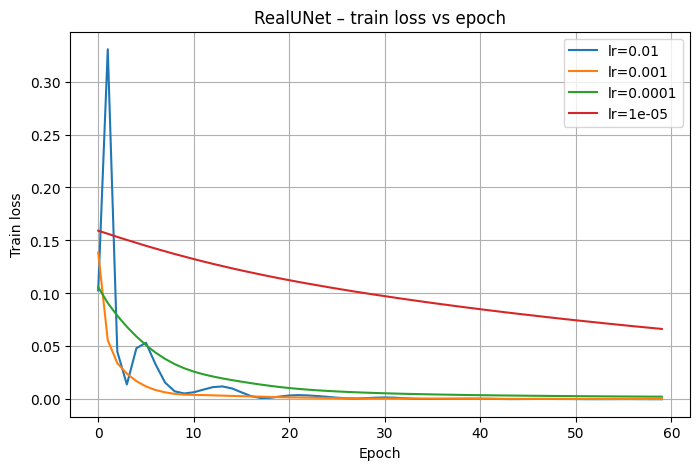

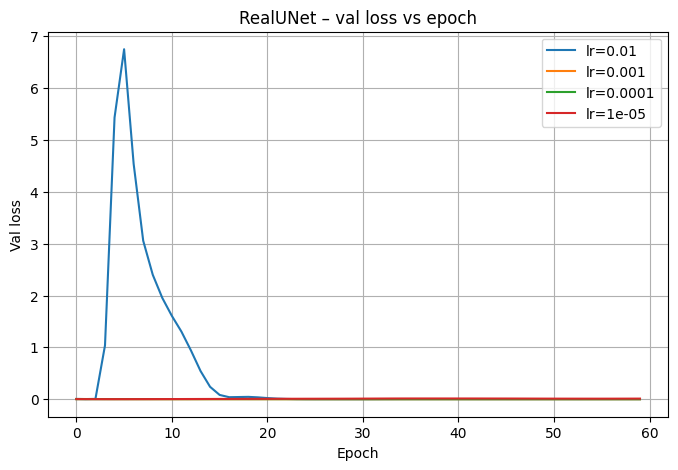

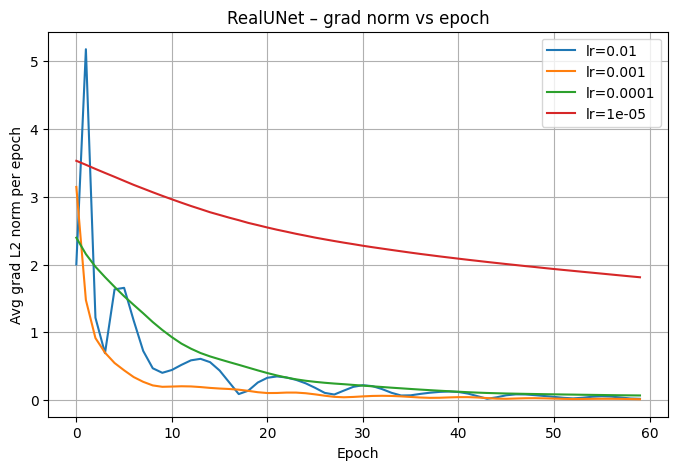

In [79]:
plot_real_train_loss(real_results)
plot_real_val_loss(real_results)
plot_real_grad_norm(real_results)


In [ ]:
plot_real_val_and_grad(real_results, label_prefix="RealUNet")

## Compare CVNN and Real

In [30]:
cv_and_real_results = dict(all_results)  # shallow copy

cv_and_real_results["RealUNet"] = {}
for lr, metrics in real_results.items():
    cv_and_real_results["RealUNet"][lr] = {
        "train_loss": metrics["train_loss"],
        "val_loss":   metrics["val_loss"],
        "grad_norm":  metrics["grad_norm"],
    }

## Default Complex Initialization 0 + 0j with real 

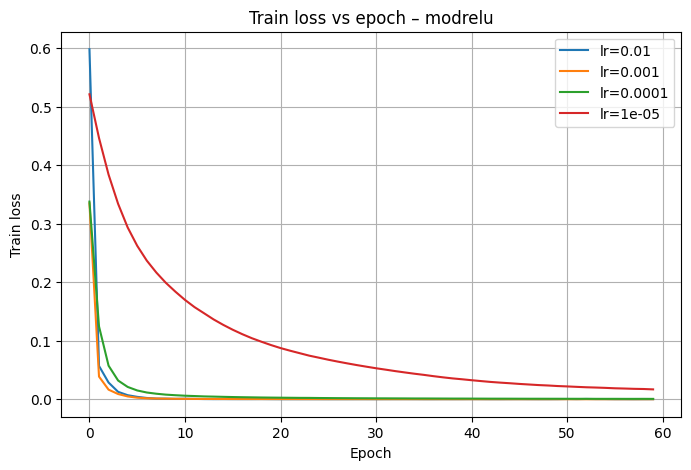

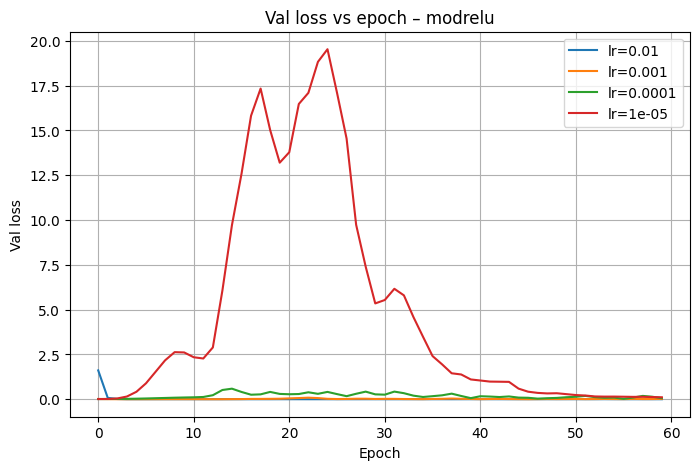

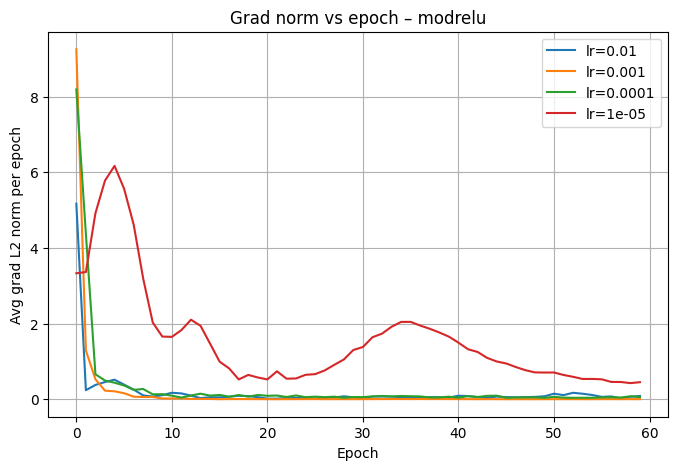

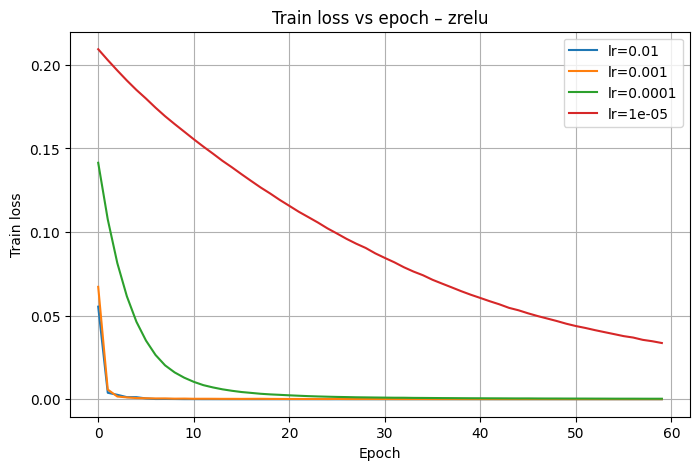

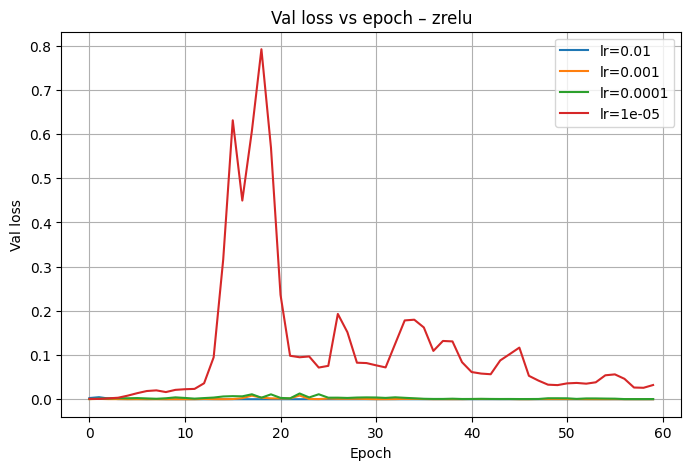

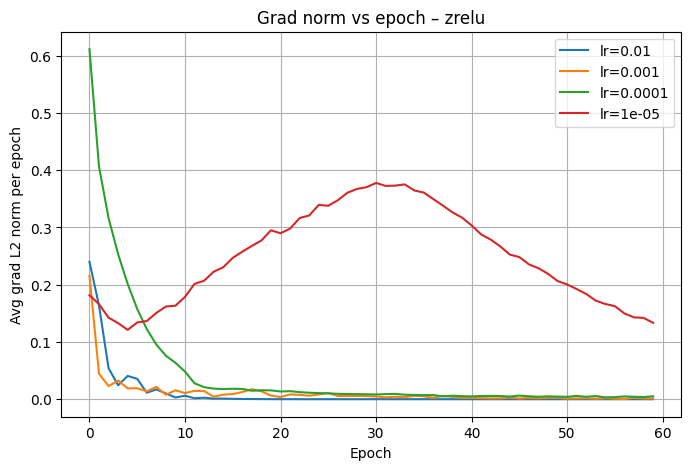

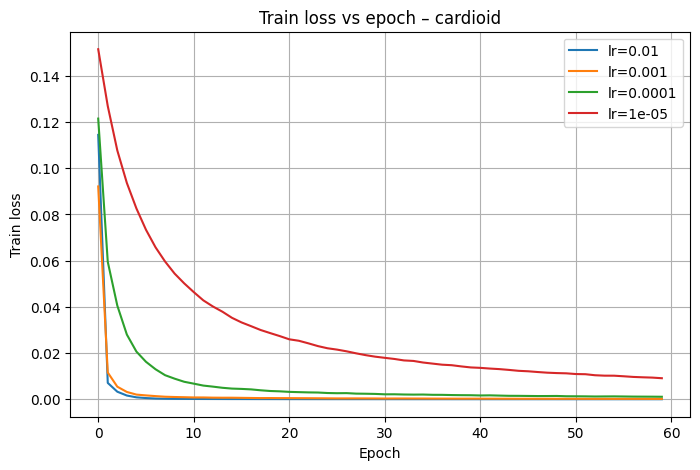

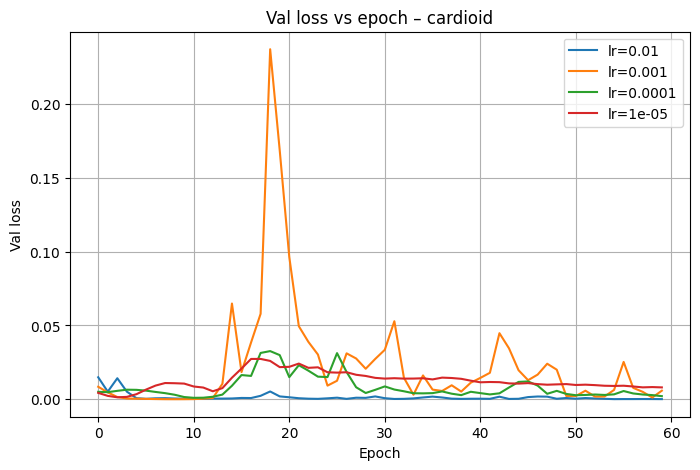

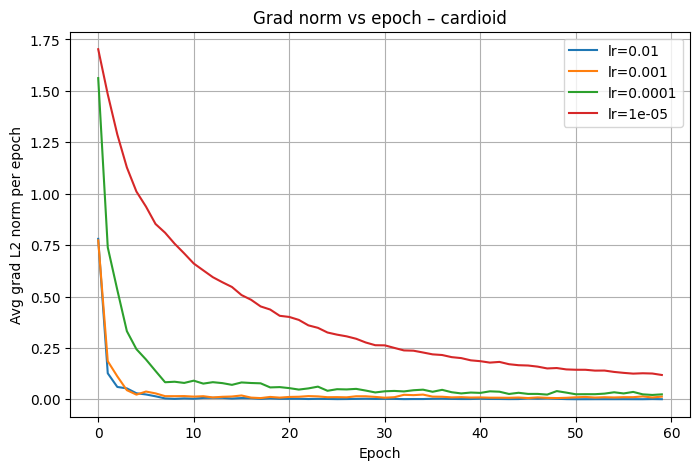

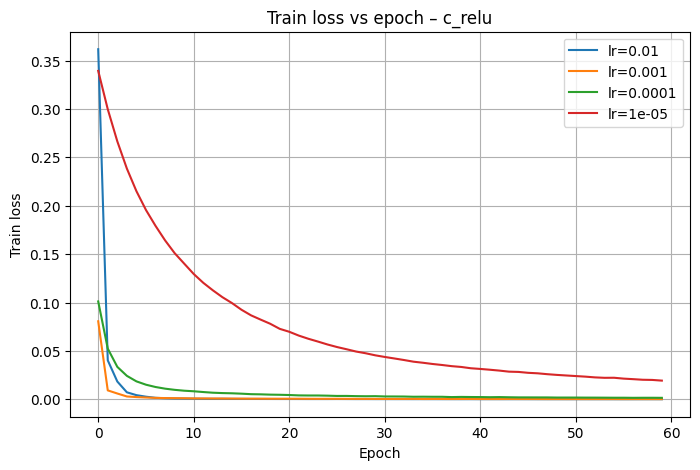

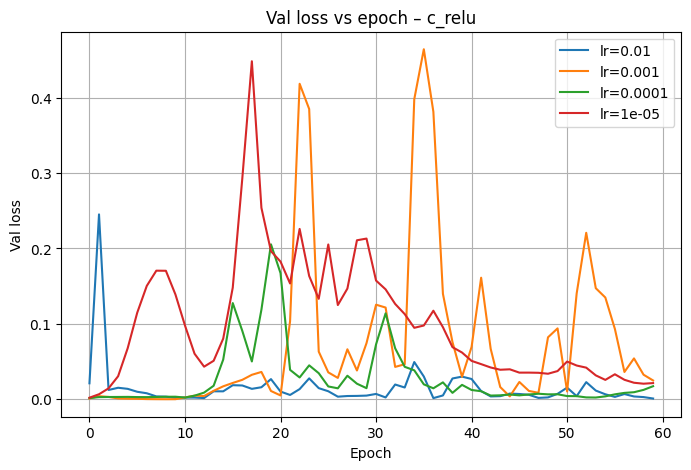

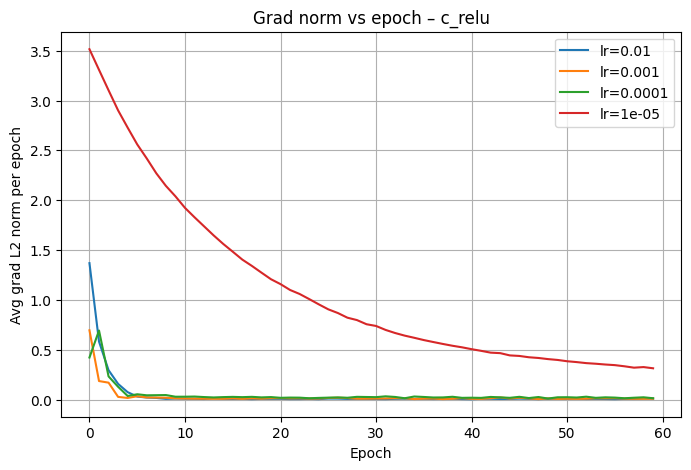

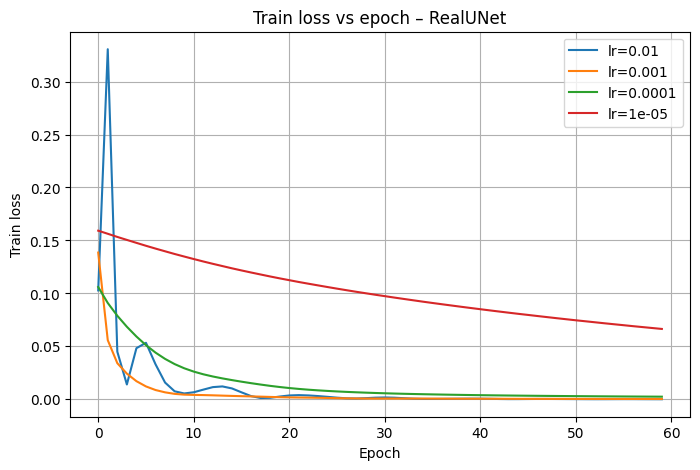

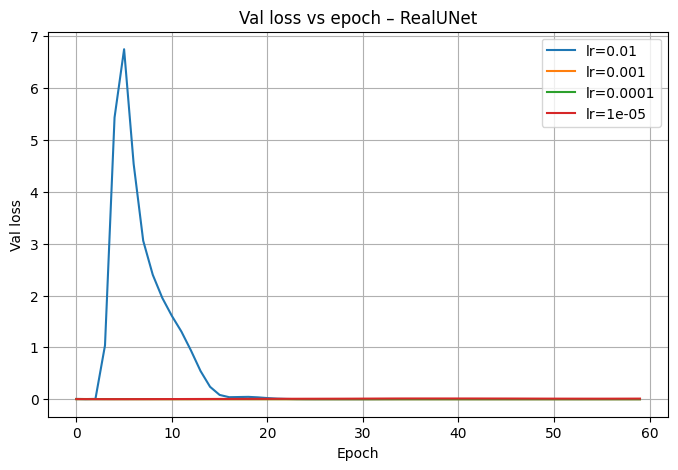

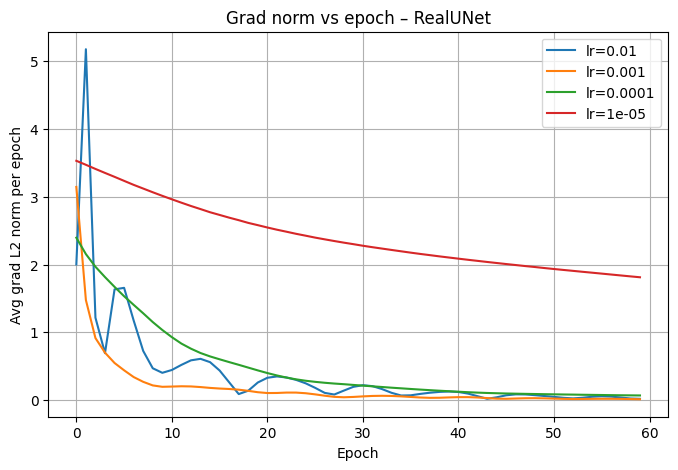

In [31]:
for act_name in activations_to_test + ["RealUNet"]:
    plot_train_loss_for_activation(cv_and_real_results, act_name)
    plot_val_loss_for_activation(cv_and_real_results, act_name)
    plot_grad_norm_for_activation(cv_and_real_results, act_name)

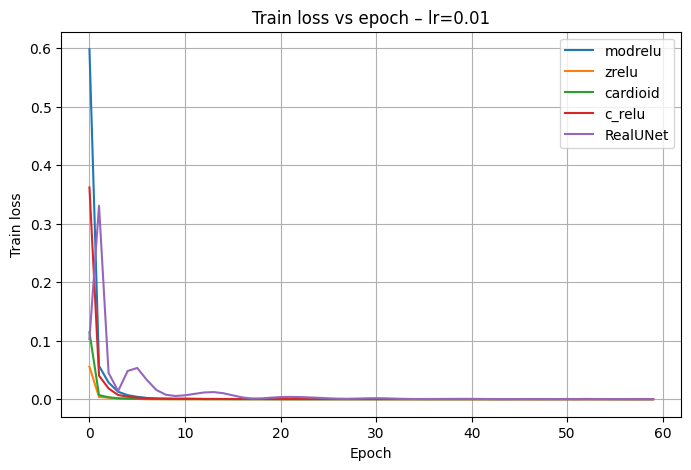

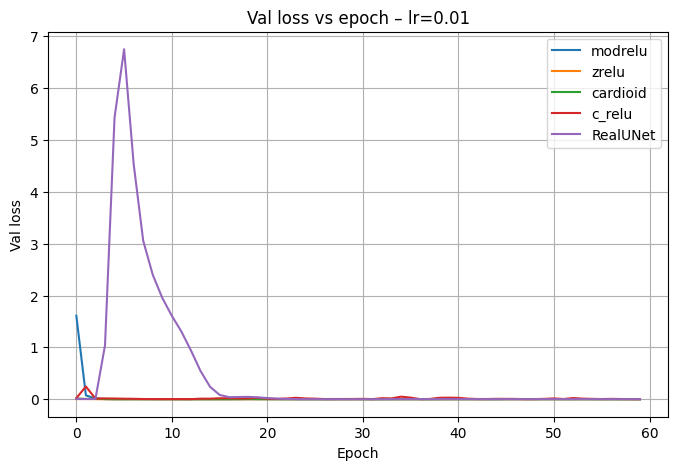

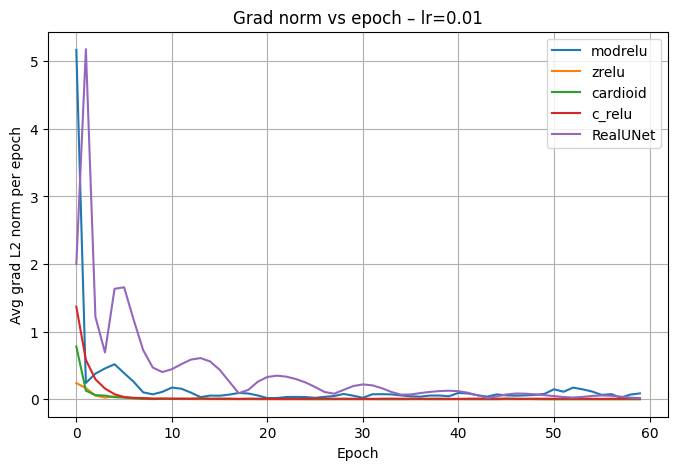

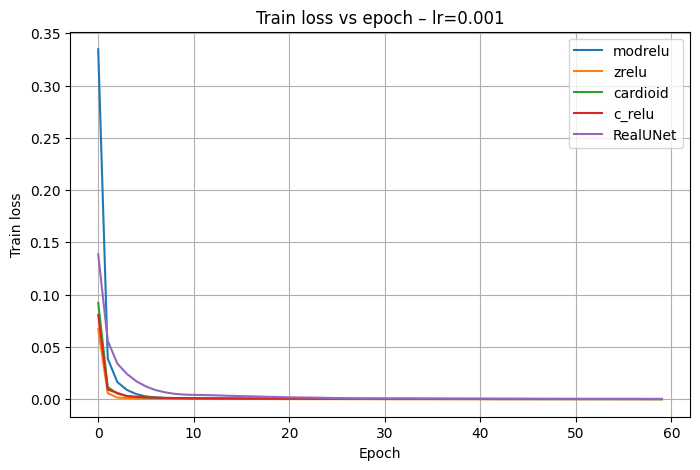

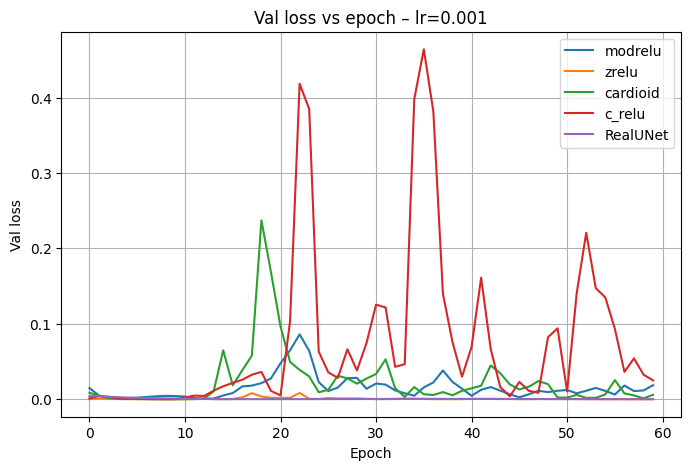

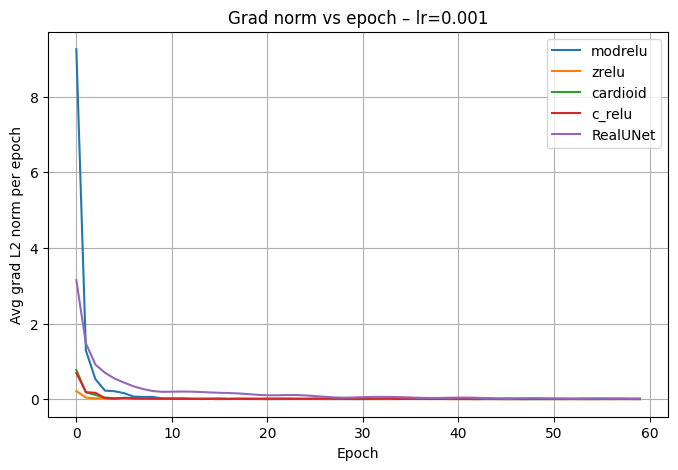

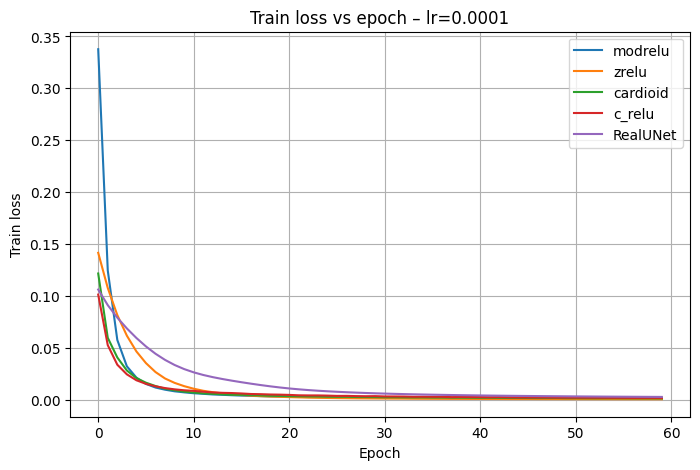

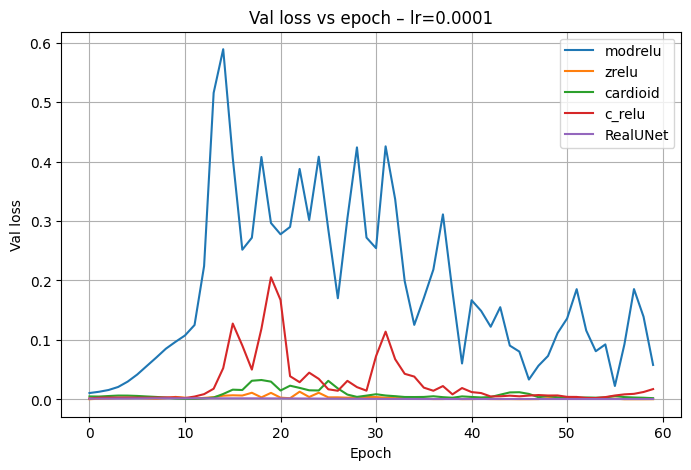

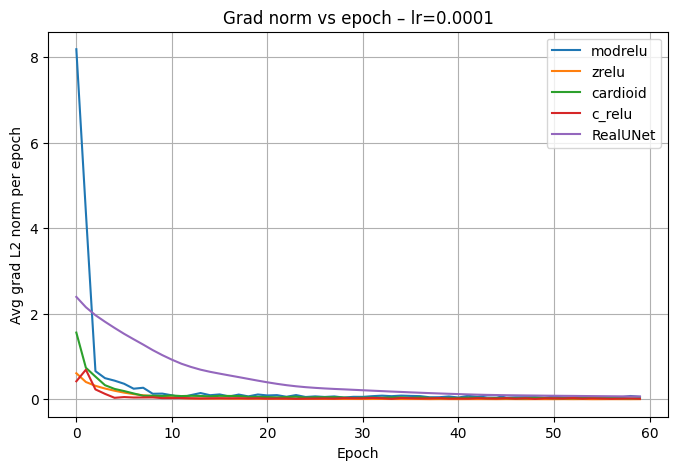

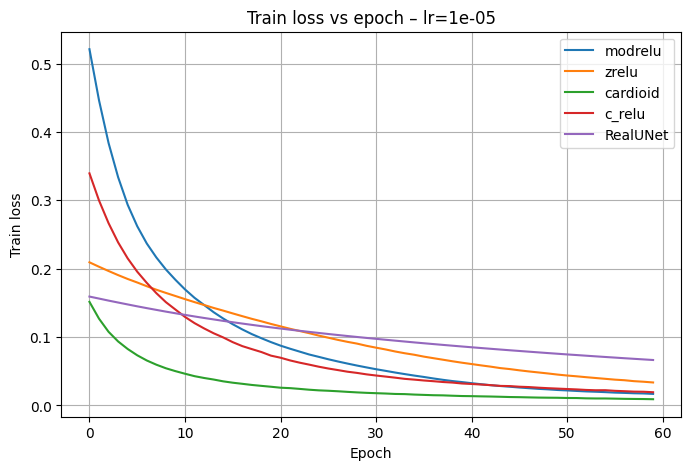

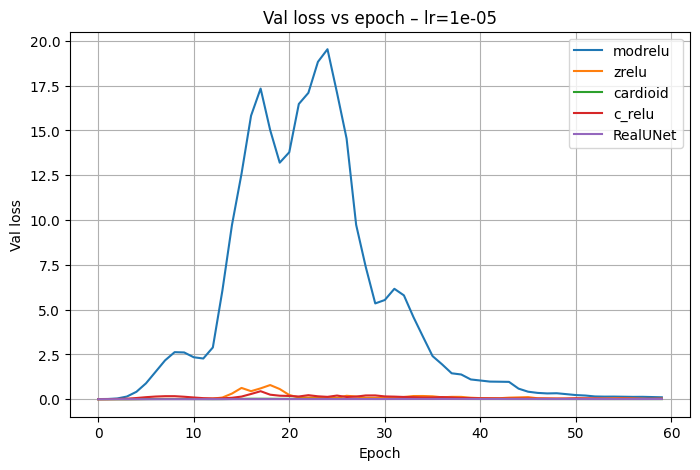

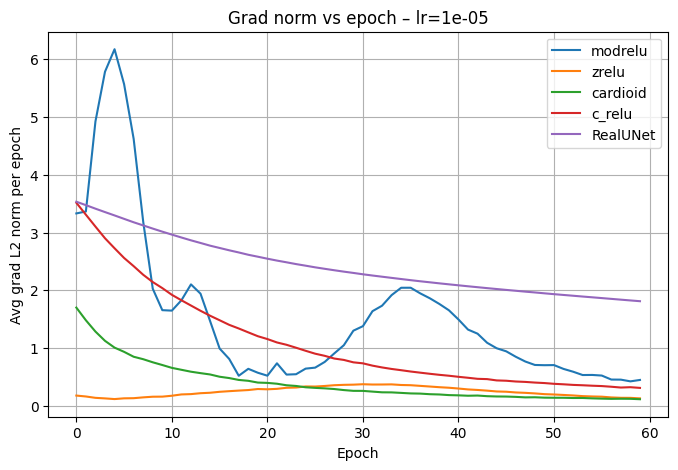

In [32]:
for lr in [1e-2, 1e-3, 1e-4, 1e-5]:
    plot_train_loss_for_lr(cv_and_real_results, lr=lr)
    plot_val_loss_for_lr(cv_and_real_results, lr=lr)
    plot_grad_norm_for_lr(cv_and_real_results, lr=lr)

## Xavier Initialization

In [33]:
all_results = torch.load("cvnn_lr_sweep_results_complex_xavier.pt")

cv_and_real_results = dict(all_results)  # shallow copy

cv_and_real_results["RealUNet"] = {}
for lr, metrics in real_results.items():
    cv_and_real_results["RealUNet"][lr] = {
        "train_loss": metrics["train_loss"],
        "val_loss":   metrics["val_loss"],
        "grad_norm":  metrics["grad_norm"],
    }

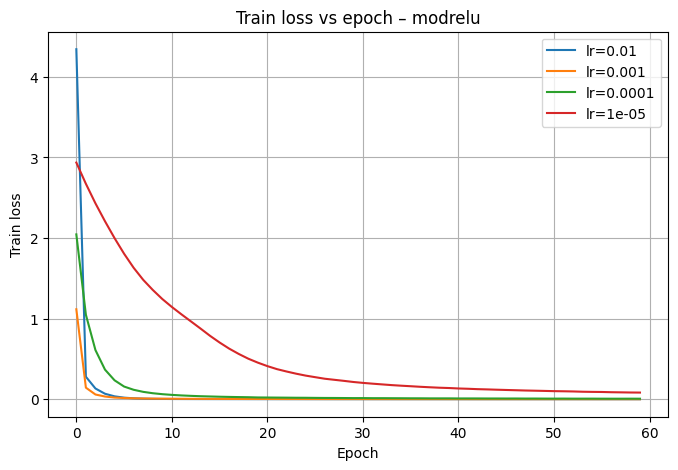

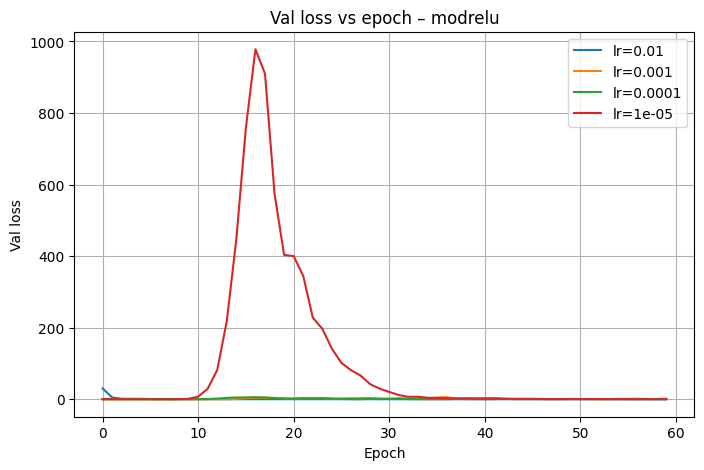

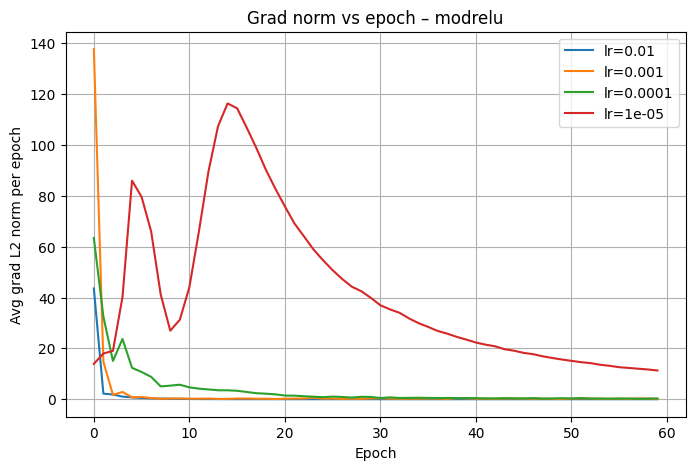

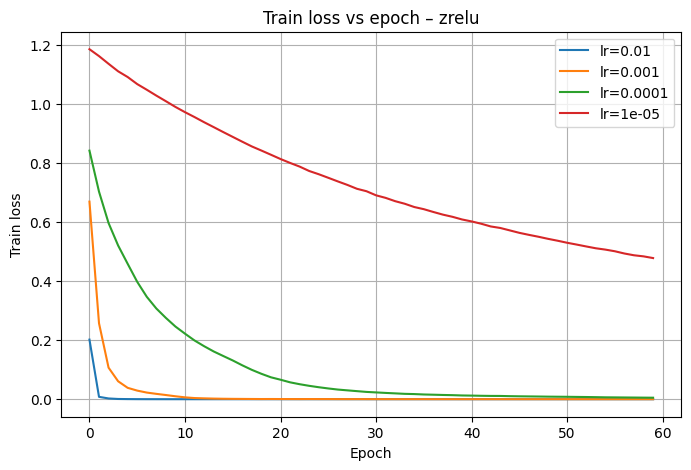

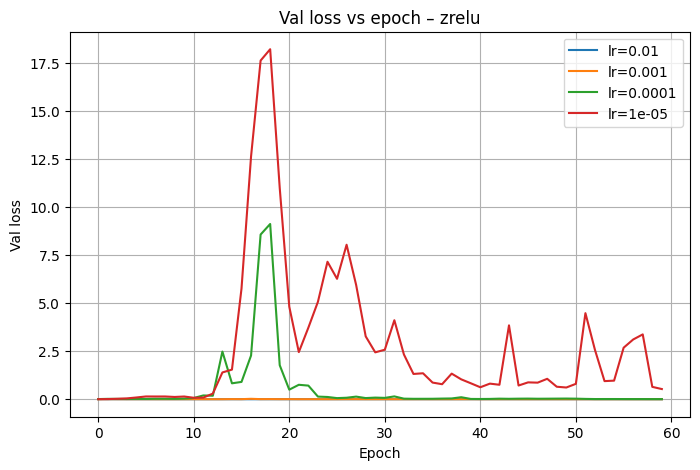

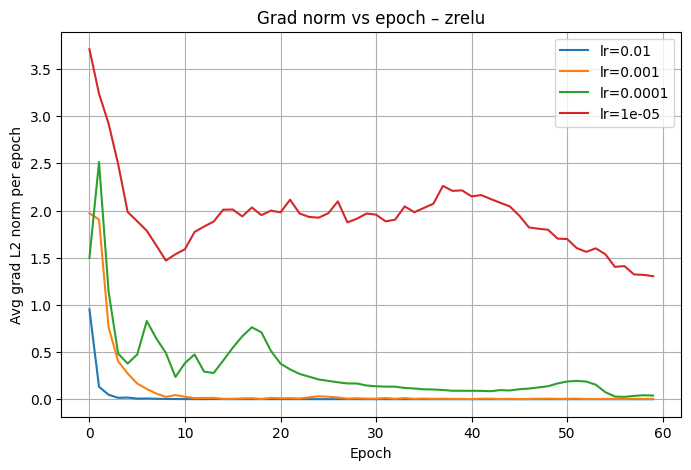

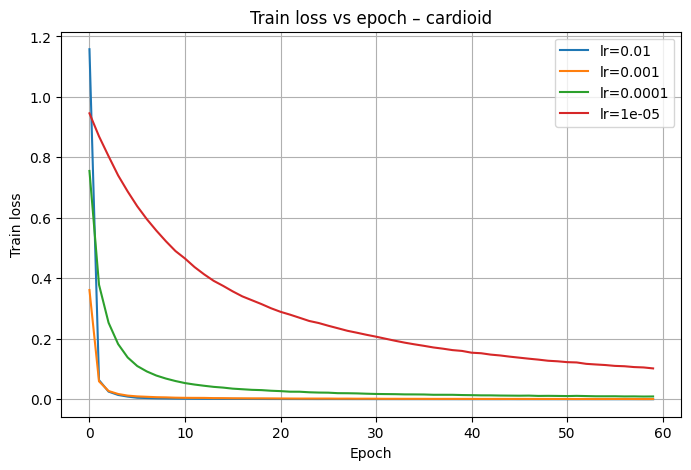

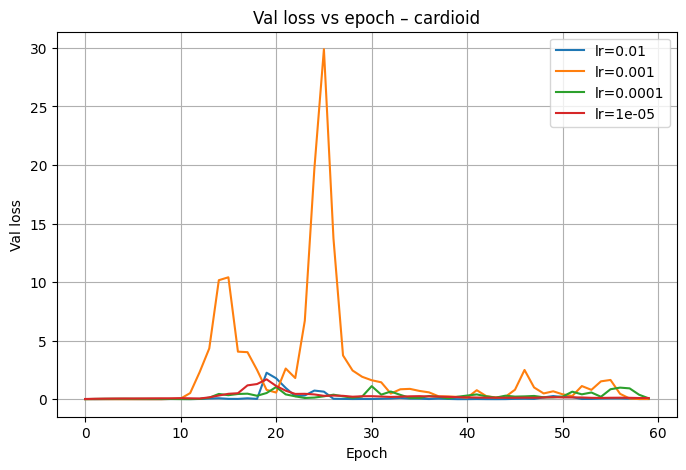

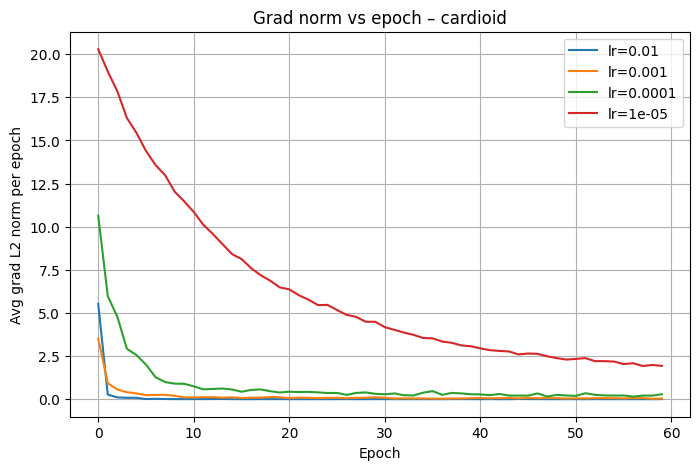

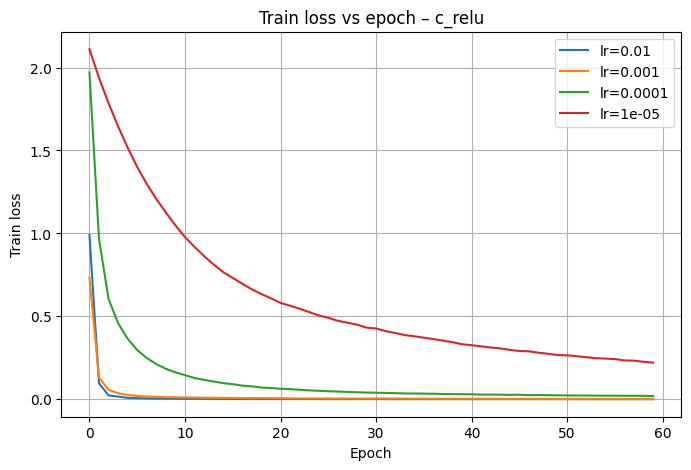

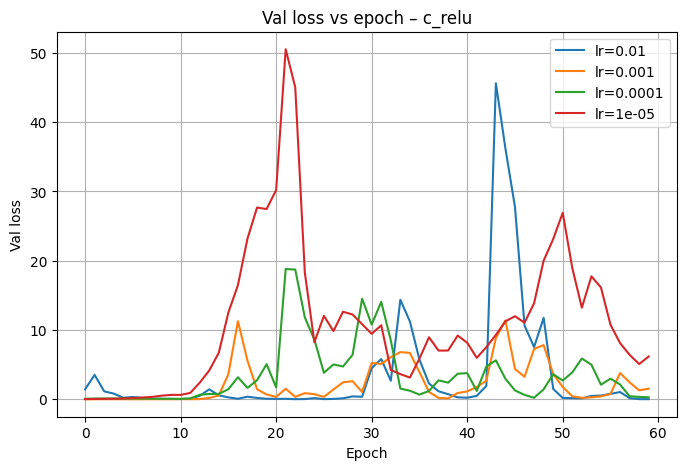

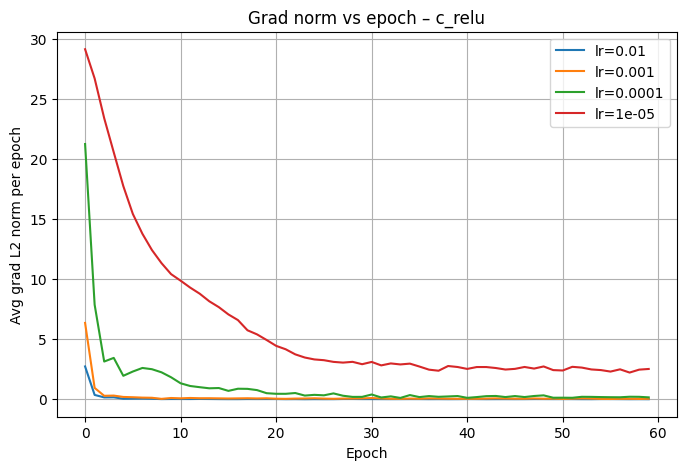

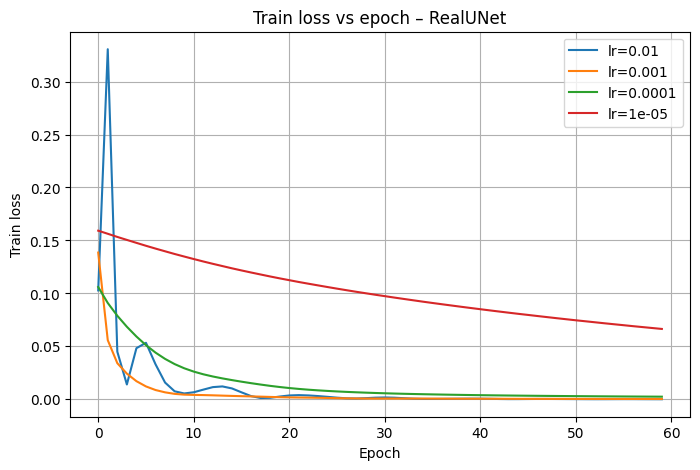

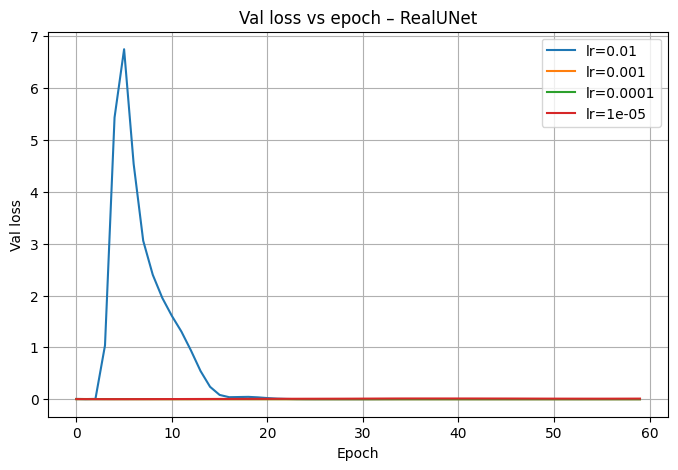

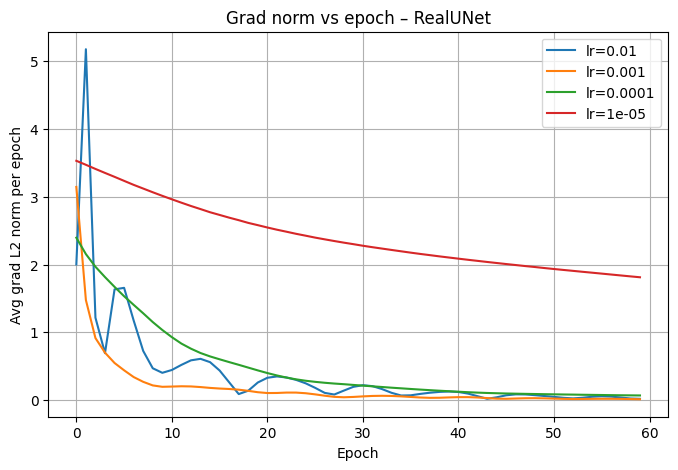

In [34]:
for act_name in activations_to_test + ["RealUNet"]:
    plot_train_loss_for_activation(cv_and_real_results, act_name)
    plot_val_loss_for_activation(cv_and_real_results, act_name)
    plot_grad_norm_for_activation(cv_and_real_results, act_name)

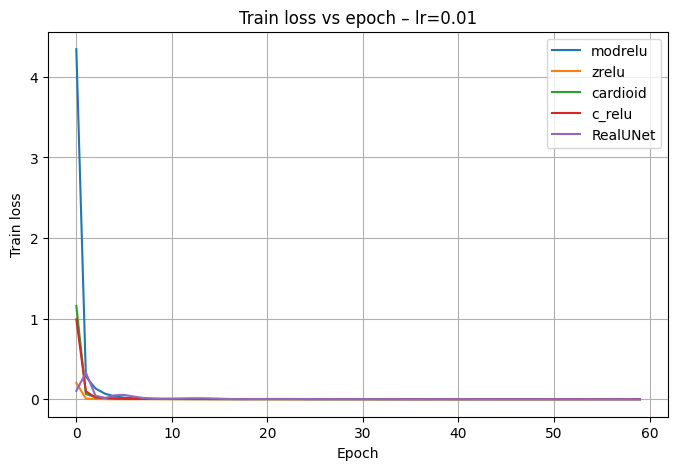

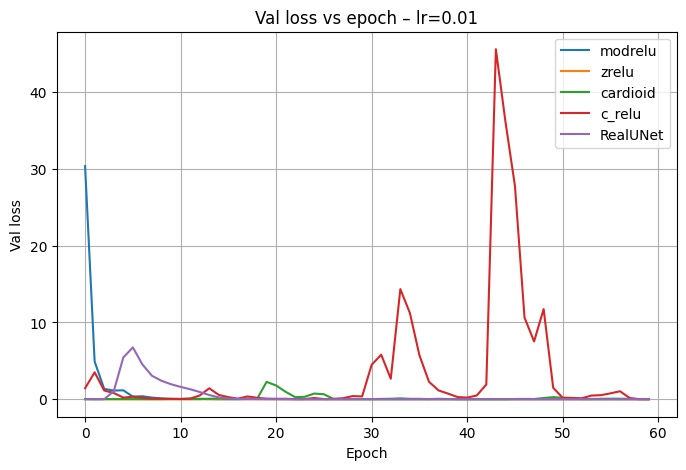

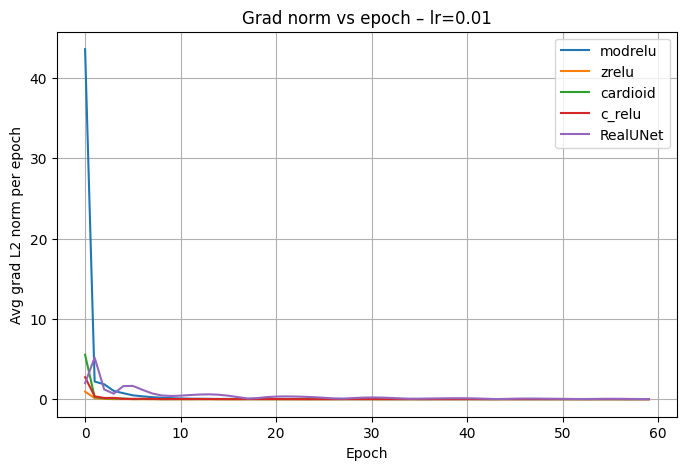

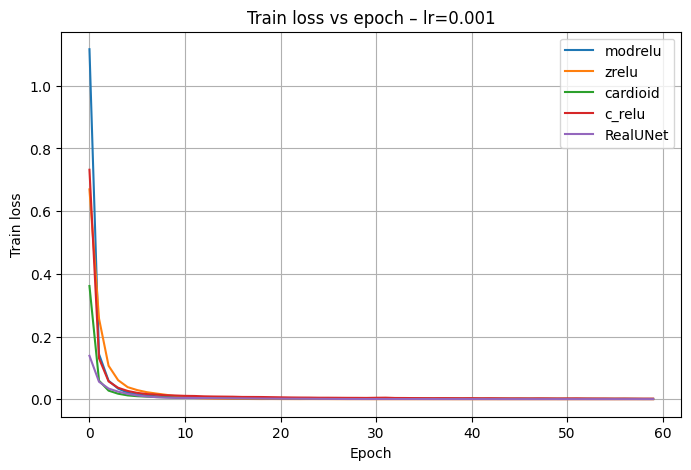

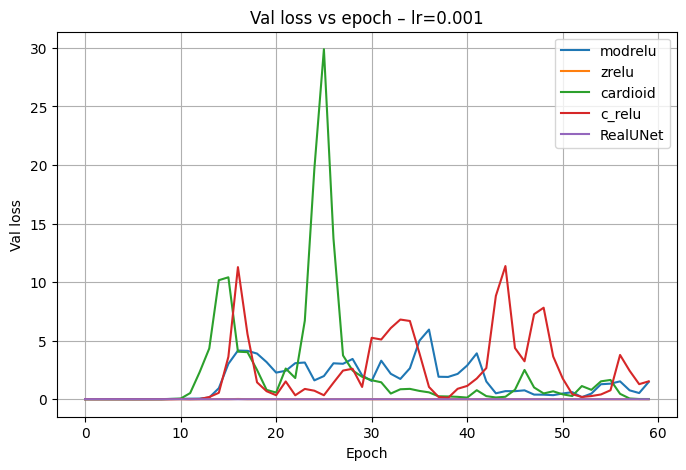

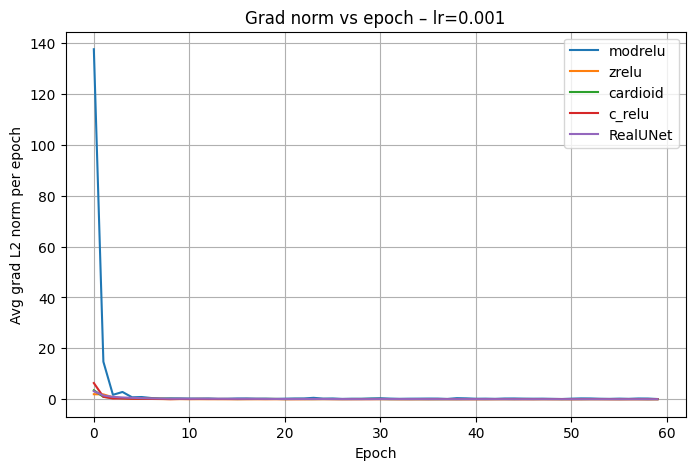

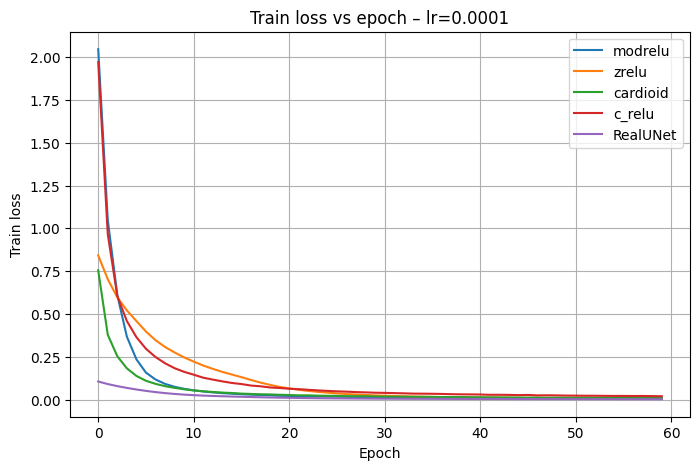

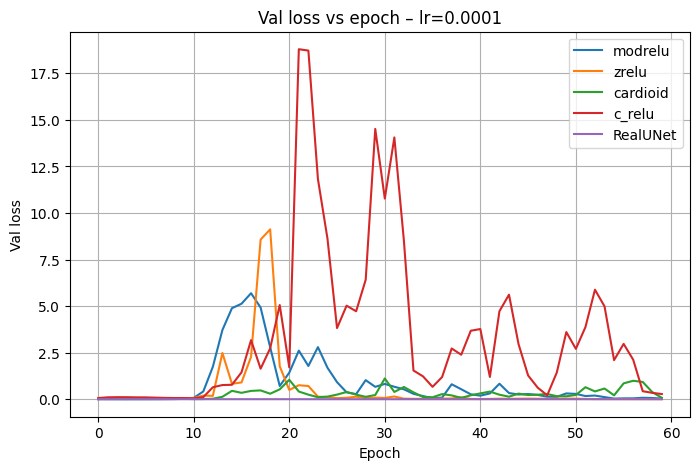

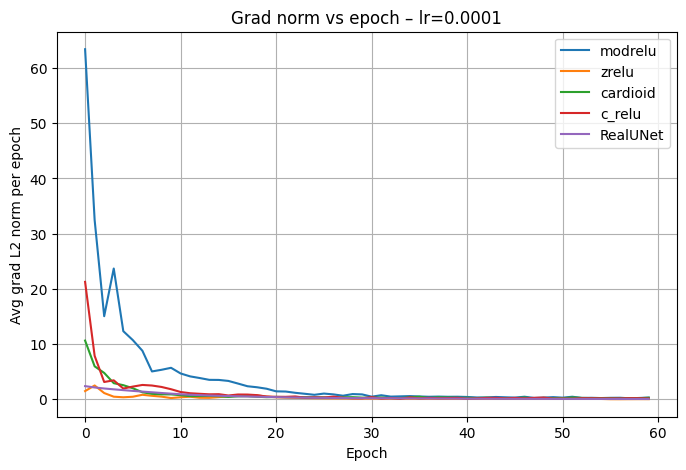

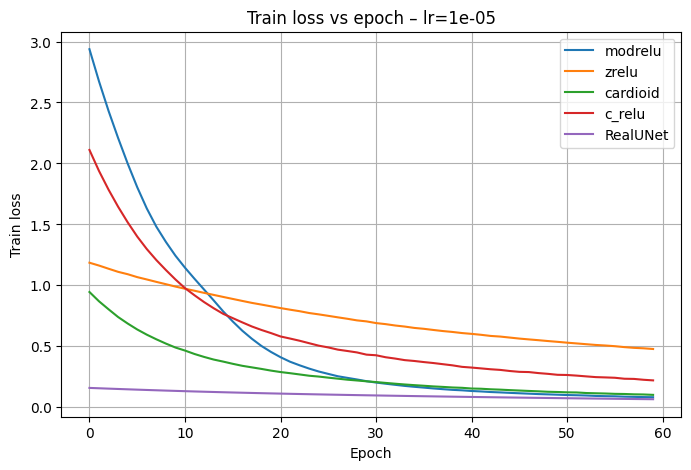

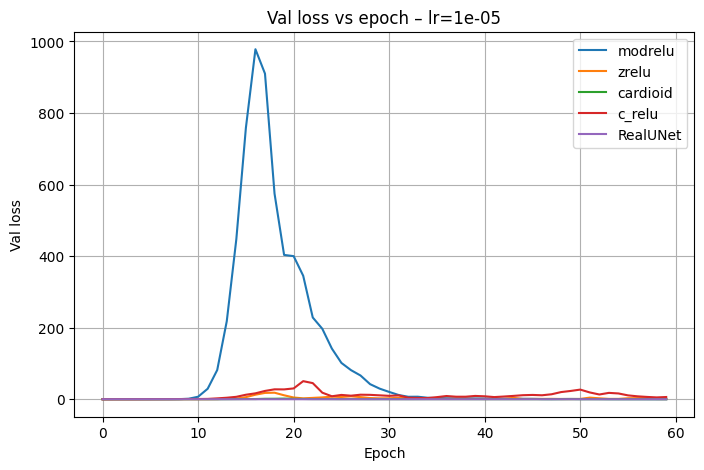

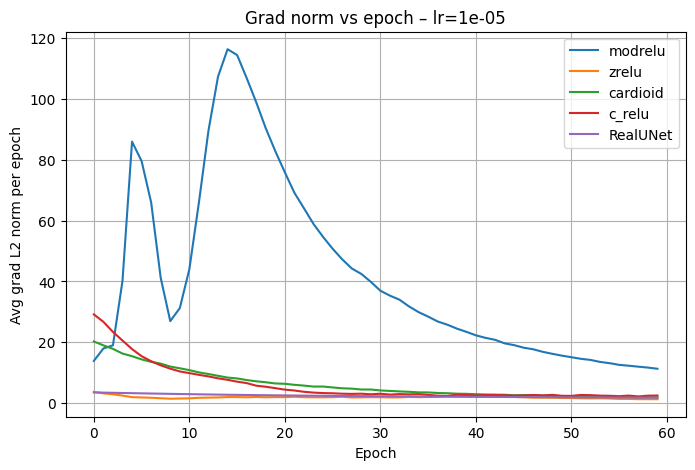

In [35]:
for lr in [1e-2, 1e-3, 1e-4, 1e-5]:
    plot_train_loss_for_lr(cv_and_real_results, lr=lr)
    plot_val_loss_for_lr(cv_and_real_results, lr=lr)
    plot_grad_norm_for_lr(cv_and_real_results, lr=lr)